# Dyck-(2,3) CFG next-token results and probes

This notebook loads the completed Dyck-(2,3) CFG next-token runs by default, then inspects the probe layout used by the long Dyck and Dyck-k notebooks: fixed-prefix sufficient-statistic probes, stack/top-of-stack probes, PCA views, supervised projection views, prefix sweeps, and direction arithmetic. Set `RUN_TRAINING = True` only when intentionally regenerating all 12 runs.

In [1]:
from pathlib import Path
import json
import sys

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

try:
    from sklearn.decomposition import PCA
except Exception:
    PCA = None

from hse.analysis.probes.linear import extract_linear_weight, fit_logistic_probe, fit_ridge_probe
from hse.experiments.dyck23 import DYCK23_LENGTH_BINS, DYCK23_MODEL_SPECS, run_dyck23_suite
from hse.tasks.dyck23 import Dyck23Config, Dyck23Sampler, validate_dyck23_tokens
from hse.utils.labels_io import load_labels


/home/hp_twist_shan/miniforge3/envs/hse/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
RESULTS_ROOT = ROOT / 'results' / 'dyck23_cfg_next_token'
FIGURES_ROOT = RESULTS_ROOT / 'figures'
FIGURES_ROOT.mkdir(parents=True, exist_ok=True)

MODEL_TYPES = ['rnn', 'lstm', 'transformer', 'mamba']
SEED = 0
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

RUN_TRAINING = False  # Results are already trained; set True only to intentionally retrain all 12 runs.
TRAIN_EXAMPLES = 10_000
TEST_EXAMPLES = 2_000
PROBE_EXAMPLES = 1_024
TRAINING_STEPS = 15_000
EPOCHS = 20
BATCH_SIZE = 128
MAX_PROBE_ROWS = 20_000

BALANCE_PROBE_BY = 'depth_top_class'
PROBE_MIN_CLASS_COUNT = 8
PROBE_MAX_PER_CLASS = 128
PCA_MAX_POINTS = 5_000

RIDGE_TARGETS = [
    'left', 'right', 'height',
    'left_round', 'right_round', 'height_round',
    'left_square', 'right_square', 'height_square',
]
CLASS_TARGETS = ['top_type_class', 'depth_top_class', 'legal_next_class', 'height_class']
COUNTER_TARGET_PAIRS = [
    ('height_round', 'height_square'),
    ('left_round', 'left_square'),
    ('right_round', 'right_square'),
]
GRID_TARGET_PAIRS = [
    ('height_round', 'height_square'),
    ('left_round', 'left_square'),
]
COUNTER_TOTAL_TARGETS = {
    ('height_round', 'height_square'): 'height',
    ('left_round', 'left_square'): 'left',
    ('right_round', 'right_square'): 'right',
}


FIXED_PREFIX_BY_BIN = {
    'len_0_40': 20,
    'len_40_80': 60,
    'len_80_120': 100,
}
SWEEP_PREFIX_BY_BIN = {
    'len_0_40': list(range(4, 41, 4)),
    'len_40_80': list(range(44, 81, 4)),
    'len_80_120': list(range(84, 121, 4)),
}

pd.DataFrame([
    {'model': name, **{k: v for k, v in spec.items() if k != 'state_kind'}}
    for name, spec in DYCK23_MODEL_SPECS.items()
])


,model,layers,emb_dim,hidden_dim,dropout,learned_initial_state,fused,n_heads,ffn_dim,pos_encoding,embed_scale,final_layer_norm,state_dim,expansion_factor,require_official_mamba
0,rnn,5,80,80,0.1,True,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,lstm,5,40,40,0.1,True,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,transformer,5,32,32,0.1,NaN,NaN,8.0,128.0,sinusoidal,True,True,NaN,NaN,NaN
3,mamba,5,36,36,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.0,2.0,True


整个 notebook 的全局设置：4 个模型、是否重新训练、15k training steps、固定 prefix、prefix sweep，以及后面要 probe 的 regression/classification target。展示 4 个模型的结构参数表。

## 1. Load the 12 trained runs

The trained checkpoints, hidden states, labels, and probe summaries are already under `results/dyck23_cfg_next_token`. This cell only reads those artifacts unless `RUN_TRAINING` is explicitly set to `True`.

In [3]:
runs_path = RESULTS_ROOT / 'runs.csv'
probe_path = RESULTS_ROOT / 'probe_summary.csv'

if RUN_TRAINING:
    runs_df, probe_df = run_dyck23_suite(
        seed=SEED,
        models=MODEL_TYPES,
        train_examples=TRAIN_EXAMPLES,
        test_examples=TEST_EXAMPLES,
        probe_examples=PROBE_EXAMPLES,
        steps=TRAINING_STEPS,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        max_probe_rows=MAX_PROBE_ROWS,
        device=DEVICE,
        results_root=RESULTS_ROOT,
    )
else:
    if not runs_path.exists() or not probe_path.exists():
        raise FileNotFoundError(
            f'Missing {runs_path} or {probe_path}. Set RUN_TRAINING = True only if you need to regenerate them.'
        )
    runs_df = pd.read_csv(runs_path)
    probe_df = pd.read_csv(probe_path)

expected_runs = len(MODEL_TYPES) * len(DYCK23_LENGTH_BINS)

if len(runs_df) != expected_runs or len(probe_df) != expected_runs:
    run_rows = []
    probe_rows = []
    for length_bin in DYCK23_LENGTH_BINS:
        for model_type in MODEL_TYPES:
            run_dir = RESULTS_ROOT / length_bin / f'{model_type}_seed{SEED}'
            config_path = run_dir / 'config.json'
            metrics_path = run_dir / 'metrics.json'
            if not config_path.exists() or not metrics_path.exists():
                raise FileNotFoundError(f'Missing completed artifacts under {run_dir}')
            config = json.load(open(config_path))
            metrics = json.load(open(metrics_path))
            labels_path = run_dir / 'labels.parquet'
            if labels_path.exists():
                hidden_rows = len(pd.read_parquet(labels_path, columns=['example_id']))
            else:
                hidden_rows = len(pd.read_csv(run_dir / 'labels.csv', usecols=['example_id']))
            eval_metrics = metrics['eval']
            hidden_dim = int(config['model'].get('hidden_dim', config['model'].get('emb_dim')))
            run_rows.append({
                'length_bin': length_bin,
                'model': model_type,
                'seed': config['seed'],
                'run_dir': str(run_dir.resolve()),
                'loss': eval_metrics['loss'],
                'accuracy': eval_metrics['accuracy'],
                'dyck_accuracy': eval_metrics['dyck_accuracy'],
                'hidden_rows': hidden_rows,
                'hidden_dim': hidden_dim,
                'params': config['trainable_parameters'],
                'backbone_params': config['backbone_parameters_excluding_lm_head'],
                'elapsed_seconds': metrics.get('elapsed_seconds'),
            })
            probe_rows.append({
                'length_bin': length_bin,
                'model': model_type,
                'seed': config['seed'],
                **metrics.get('probe', {}),
                **metrics.get('compression', {}),
            })
    runs_df = pd.DataFrame(run_rows)
    probe_df = pd.DataFrame(probe_rows)
    runs_df.to_csv(runs_path, index=False)
    probe_df.to_csv(probe_path, index=False)

if len(runs_df) != expected_runs or len(probe_df) != expected_runs:
    raise ValueError(f'Expected {expected_runs} runs/probe rows, got {len(runs_df)} and {len(probe_df)}.')

runs_df.sort_values(['length_bin', 'model']).reset_index(drop=True)


,length_bin,model,seed,run_dir,loss,accuracy,dyck_accuracy,hidden_rows,hidden_dim,params,backbone_params,elapsed_seconds
0,len_0_40,lstm,0,/home/hp_twist_shan/Research/Hidden State Eval...,0.878579,0.573098,0.584823,21332,40,66367,66080,144.111185
1,len_0_40,mamba,0,/home/hp_twist_shan/Research/Hidden State Eval...,0.889283,0.569357,0.579256,21332,36,61351,61092,390.039618
2,len_0_40,rnn,0,/home/hp_twist_shan/Research/Hidden State Eval...,0.880667,0.573389,0.584797,21332,80,66327,65760,121.896685
3,len_0_40,transformer,0,/home/hp_twist_shan/Research/Hidden State Eval...,0.877958,0.574094,0.587300,21332,32,64039,63808,577.540913
4,len_40_80,lstm,0,/home/hp_twist_shan/Research/Hidden State Eval...,0.844419,0.570615,0.573726,62836,40,66367,66080,138.650702
5,len_40_80,mamba,0,/home/hp_twist_shan/Research/Hidden State Eval...,0.848962,0.568112,0.569059,62836,36,61351,61092,521.444576
6,len_40_80,rnn,0,/home/hp_twist_shan/Research/Hidden State Eval...,0.845331,0.571398,0.574215,62836,80,66327,65760,119.947716
7,len_40_80,transformer,0,/home/hp_twist_shan/Research/Hidden State Eval...,0.843488,0.570795,0.574008,62836,32,64039,63808,803.157155
8,len_80_120,lstm,0,/home/hp_twist_shan/Research/Hidden State Eval...,0.838340,0.570563,0.572585,104600,40,66367,66080,150.955101
9,len_80_120,mamba,0,/home/hp_twist_shan/Research/Hidden State Eval...,0.840717,0.568057,0.569809,104600,36,61351,61092,404.528494


即 3 个长度桶 × 4 个模型。主要看 `loss`、`accuracy`、`dyck_accuracy`、`backbone_params` 和 `elapsed_seconds`。

accuracy: 所有有效 target token 上的 next-token accuracy = bracket tokens + EOS
dyck_accuracy: 只在 Dyck bracket token 上的 next-token accuracy = 只算 ( ) [ ]

## 2. Load saved probe arrays

The suite saves one row per valid next-token prediction position. For a fixed-prefix view, filter by `dyck_seen`, then balance by `depth_top_class` as in the Dyck-k long notebook.

In [4]:
def load_run_arrays(run_dir):
    run_dir = Path(run_dir)
    if not run_dir.is_absolute():
        candidates = [ROOT / run_dir, RESULTS_ROOT / run_dir]
        run_dir = next((path for path in candidates if (path / 'hidden_states.pt').exists()), ROOT / run_dir)
    hidden_path = run_dir / 'hidden_states.pt'
    if not hidden_path.exists():
        raise FileNotFoundError(f'Missing hidden states at {hidden_path}')
    hidden = torch.load(hidden_path, map_location='cpu').numpy()
    labels_path = run_dir / 'labels.parquet'
    if not labels_path.exists():
        labels_path = run_dir / 'labels.csv'
    labels = load_labels(labels_path)
    return {'X': hidden, 'labels': labels, 'run_dir': run_dir}


def select_prefix(data, prefix):
    labels = data['labels']
    mask = labels['dyck_seen'].to_numpy() == int(prefix)
    return {'X': data['X'][mask], 'labels': labels.loc[mask].reset_index(drop=True), 'run_dir': data['run_dir']}


def balance_data_by_label(data, label=BALANCE_PROBE_BY, seed=0, max_per_class=PROBE_MAX_PER_CLASS, min_per_class=PROBE_MIN_CLASS_COUNT):
    labels = data['labels']
    rng = np.random.default_rng(seed)
    chosen = []
    for _, idx in labels.groupby(label).indices.items():
        idx = np.asarray(idx)
        if len(idx) < min_per_class:
            continue
        take = min(len(idx), max_per_class) if max_per_class else len(idx)
        chosen.append(rng.choice(idx, size=take, replace=False))
    if not chosen:
        return data
    chosen = np.sort(np.concatenate(chosen))
    return {'X': data['X'][chosen], 'labels': labels.iloc[chosen].reset_index(drop=True), 'run_dir': data['run_dir']}


def print_class_balance(data, label=BALANCE_PROBE_BY, name='data', limit=12):
    counts = data['labels'][label].value_counts().sort_index()
    preview = ', '.join(f'{k}:{v}' for k, v in counts.head(limit).items())
    print(f'{name} {label} counts -> {preview}')


run_arrays = {
    (row.length_bin, row.model): load_run_arrays(row.run_dir)
    for row in runs_df.itertuples()
}


In [5]:
def _split_indices(n, seed=0, test_size=0.25):
    rng = np.random.default_rng(seed)
    idx = rng.permutation(n)
    n_test = max(1, int(round(n * test_size)))
    return idx[n_test:], idx[:n_test]


def _standardize_train_test(X_train, X_test):
    mean = X_train.mean(axis=0, keepdims=True)
    std = X_train.std(axis=0, keepdims=True)
    std[std < 1e-8] = 1.0
    return (X_train - mean) / std, (X_test - mean) / std, mean, std


def _r2_score_np(y_true, y_pred):
    ss_res = float(((y_true - y_pred) ** 2).sum())
    ss_tot = float(((y_true - y_true.mean()) ** 2).sum())
    return 1.0 - ss_res / (ss_tot + 1e-12)


def fit_ridge_train_test(X_train, y_train, X_test, y_test, name, alpha=1.0):
    X_train = np.asarray(X_train, dtype=np.float64)
    X_test = np.asarray(X_test, dtype=np.float64)
    y_train = np.asarray(y_train, dtype=np.float64)
    y_test = np.asarray(y_test, dtype=np.float64)
    X_train_s, X_test_s, mean, std = _standardize_train_test(X_train, X_test)
    X_aug = np.concatenate([X_train_s, np.ones((len(X_train_s), 1))], axis=1)
    eye = np.eye(X_aug.shape[1])
    eye[-1, -1] = 0.0
    system = X_aug.T @ X_aug + alpha * eye
    rhs = X_aug.T @ y_train
    try:
        coef_aug = np.linalg.solve(system, rhs)
    except np.linalg.LinAlgError:
        coef_aug = np.linalg.pinv(system) @ rhs
    pred = np.concatenate([X_test_s, np.ones((len(X_test_s), 1))], axis=1) @ coef_aug
    coef = coef_aug[:-1] / std.squeeze()
    intercept = float(coef_aug[-1] - (mean.squeeze() / std.squeeze()) @ coef_aug[:-1])
    return {'name': name, 'probe': {'coef': coef, 'intercept': intercept}, 'r2': float(_r2_score_np(y_test, pred)), 'mae': float(np.abs(y_test - pred).mean())}


def _shared_class_subset(X_train, y_train, X_test, y_test, min_count=2):
    train_counts = pd.Series(y_train).value_counts()
    test_counts = pd.Series(y_test).value_counts()
    keep = np.intersect1d(
        train_counts[train_counts >= min_count].index.to_numpy(),
        test_counts[test_counts >= min_count].index.to_numpy(),
    )
    train_mask = np.isin(y_train, keep)
    test_mask = np.isin(y_test, keep)
    return X_train[train_mask], y_train[train_mask], X_test[test_mask], y_test[test_mask]


def fit_logistic_train_test(X_train, y_train, X_test, y_test, name):
    X_train = np.asarray(X_train, dtype=np.float32)
    X_test = np.asarray(X_test, dtype=np.float32)
    y_train = np.asarray(y_train)
    y_test = np.asarray(y_test)
    X_train, y_train, X_test, y_test = _shared_class_subset(X_train, y_train, X_test, y_test)
    classes = np.unique(y_train)
    if len(classes) < 2 or len(X_test) == 0:
        return {'name': name, 'probe': None, 'accuracy': float('nan'), 'n_classes': int(len(classes))}
    class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
    y_train_idx = np.array([class_to_idx[v] for v in y_train], dtype=np.int64)
    y_test_idx = np.array([class_to_idx[v] for v in y_test], dtype=np.int64)
    X_train_s, X_test_s, _, std = _standardize_train_test(X_train, X_test)
    model = torch.nn.Linear(X_train_s.shape[1], len(classes))
    opt = torch.optim.LBFGS(model.parameters(), lr=0.5, max_iter=100)
    loss_fn = torch.nn.CrossEntropyLoss()
    X_train_t = torch.tensor(X_train_s, dtype=torch.float32)
    y_train_t = torch.tensor(y_train_idx, dtype=torch.long)

    def closure():
        opt.zero_grad()
        loss = loss_fn(model(X_train_t), y_train_t)
        loss.backward()
        return loss

    opt.step(closure)
    with torch.no_grad():
        pred = model(torch.tensor(X_test_s, dtype=torch.float32)).argmax(dim=-1).numpy()
    coef = model.weight.detach().numpy() / std.squeeze()[None, :]
    return {'name': name, 'probe': {'coef': coef, 'classes': classes}, 'accuracy': float((pred == y_test_idx).mean()), 'n_classes': int(len(classes))}


def run_stack_probes(data, seed=0):
    X = data['X']
    labels = data['labels']
    train_idx, test_idx = _split_indices(len(labels), seed=seed)
    fitted = {}
    rows = []

    for target in RIDGE_TARGETS:
        if target not in labels:
            continue
        result = fit_ridge_train_test(X[train_idx], labels[target].to_numpy()[train_idx], X[test_idx], labels[target].to_numpy()[test_idx], target)
        fitted[f'ridge_{target}'] = result
        rows.append({'probe_type': 'ridge', 'target': target, 'r2': result['r2'], 'mae': result['mae']})

    for target in CLASS_TARGETS:
        if target not in labels or labels[target].nunique() <= 1:
            continue
        y = labels[target].to_numpy()
        result = fit_logistic_train_test(X[train_idx], y[train_idx], X[test_idx], y[test_idx], target)
        fitted[f'logistic_{target}'] = result
        rows.append({'probe_type': 'logistic', 'target': target, 'accuracy': result['accuracy'], 'n_classes': labels[target].nunique()})
    return fitted, pd.DataFrame(rows)


fixed_probe_results = {}
fixed_probe_rows = []
for length_bin in DYCK23_LENGTH_BINS:
    prefix = FIXED_PREFIX_BY_BIN[length_bin]
    for model_type in MODEL_TYPES:
        raw = select_prefix(run_arrays[(length_bin, model_type)], prefix)
        balanced = balance_data_by_label(raw, seed=SEED)
        print_class_balance(balanced, name=f'{length_bin} {model_type} prefix={prefix}')
        fitted, table = run_stack_probes(balanced, seed=SEED)
        fixed_probe_results[(length_bin, model_type)] = {'data': balanced, 'fitted': fitted, 'table': table, 'prefix': prefix}
        for row in table.to_dict('records'):
            fixed_probe_rows.append({'length_bin': length_bin, 'model': model_type, 'prefix': prefix, **row})

fixed_probe_df = pd.DataFrame(fixed_probe_rows)
fixed_probe_df.to_csv(RESULTS_ROOT / 'fixed_prefix_probe_summary.csv', index=False)
fixed_probe_df


len_0_40 rnn prefix=20 depth_top_class counts -> 0:128, 7:128, 8:128


len_0_40 lstm prefix=20 depth_top_class counts -> 0:128, 7:128, 8:128


len_0_40 transformer prefix=20 depth_top_class counts -> 0:128, 7:128, 8:128


len_0_40 mamba prefix=20 depth_top_class counts -> 0:128, 7:128, 8:128


len_40_80 rnn prefix=60 depth_top_class counts -> 0:128, 7:128, 8:128


...

len_80_120 rnn prefix=100 depth_top_class counts -> 0:128, 7:128, 8:128


len_80_120 lstm prefix=100 depth_top_class counts -> 0:128, 7:128, 8:128


len_80_120 transformer prefix=100 depth_top_class counts -> 0:128, 7:128, 8:128


len_80_120 mamba prefix=100 depth_top_class counts -> 0:128, 7:128, 8:128


,length_bin,model,prefix,probe_type,target,r2,mae,accuracy,n_classes
0,len_0_40,rnn,20,ridge,left,0.999992,0.001094,NaN,NaN
1,len_0_40,rnn,20,ridge,right,0.999992,0.001094,NaN,NaN
2,len_0_40,rnn,20,ridge,height,0.999992,0.002187,NaN,NaN
3,len_0_40,rnn,20,ridge,left_round,0.170855,1.285715,NaN,NaN
4,len_0_40,rnn,20,ridge,right_round,-0.015711,1.289356,NaN,NaN
...,...,...,...,...,...,...,...,...,...
151,len_80_120,mamba,100,ridge,height_square,0.859866,0.205442,NaN,NaN
152,len_80_120,mamba,100,logistic,top_type_class,NaN,NaN,1.0000,3.0
153,len_80_120,mamba,100,logistic,depth_top_class,NaN,NaN,1.0000,3.0
154,len_80_120,mamba,100,logistic,legal_next_class,NaN,NaN,0.6875,4.0


在固定 prefix 上重新拟合一组轻量 probe：读出总 left/right/height、两类括号的 per-type counter、top type、depth+top、legal next 等。它保存 `fixed_prefix_probe_summary.csv`。

depth_top_class 是一个把 当前栈深度 depth 和 当前栈顶括号类型 top type 合在一起的分类标签。

较高的 `height_*_r2` 表示 hidden state 里可以线性读出对应 counter；较高的 `top_type_class_accuracy` 和 `depth_top_class_accuracy` 表示栈顶和深度信息可读。

## 3. PCA views and same-counter stack slices

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/pca/len_0_40_rnn_pca.png


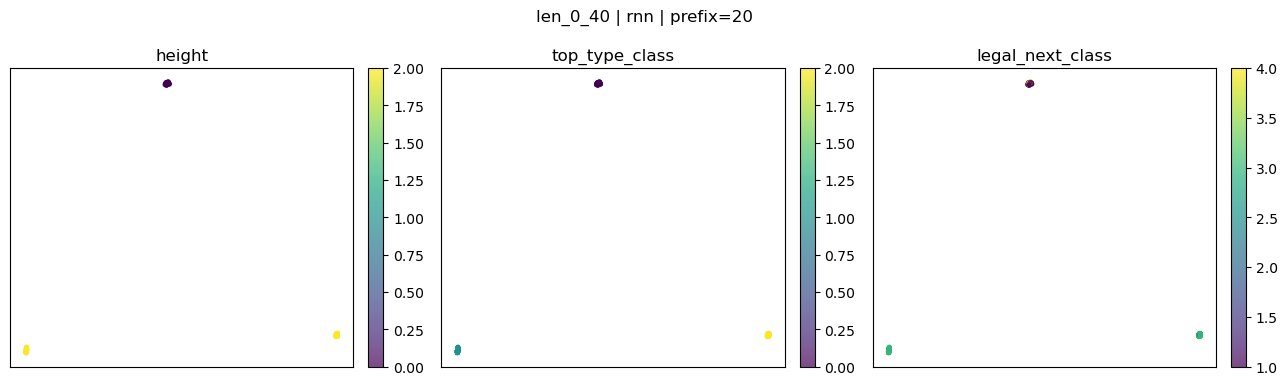

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/stack_slices/len_0_40_rnn_same_counters_diff_stack.png


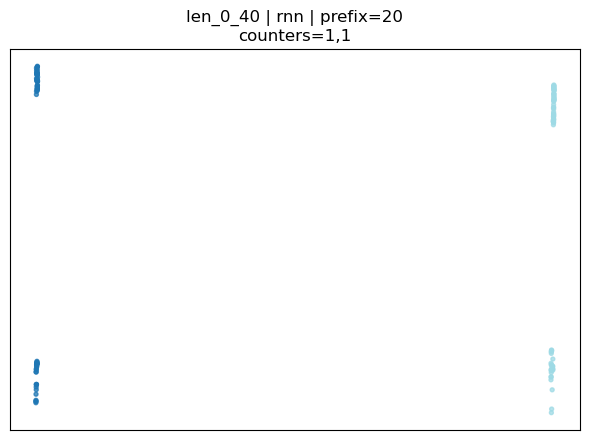

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/pca/len_0_40_lstm_pca.png


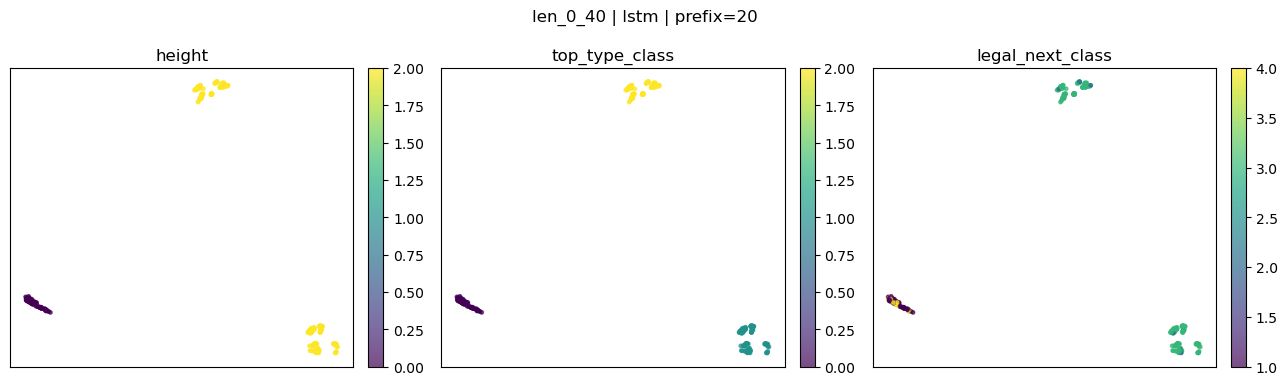

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/stack_slices/len_0_40_lstm_same_counters_diff_stack.png


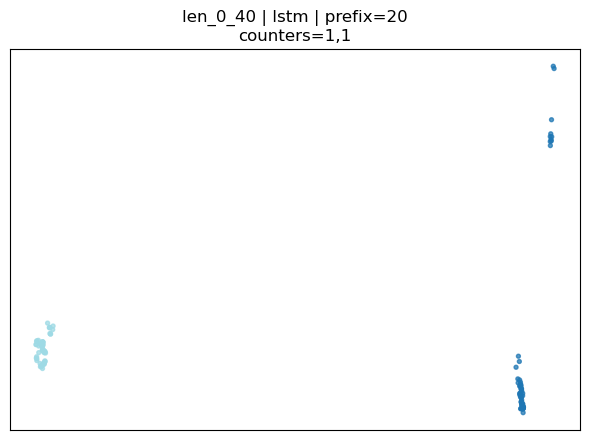

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/pca/len_0_40_transformer_pca.png


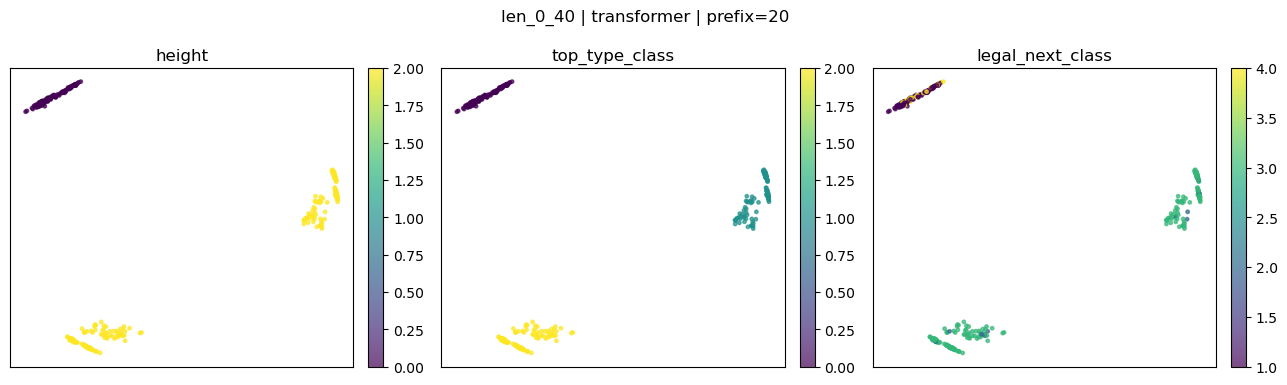

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/stack_slices/len_0_40_transformer_same_counters_diff_stack.png


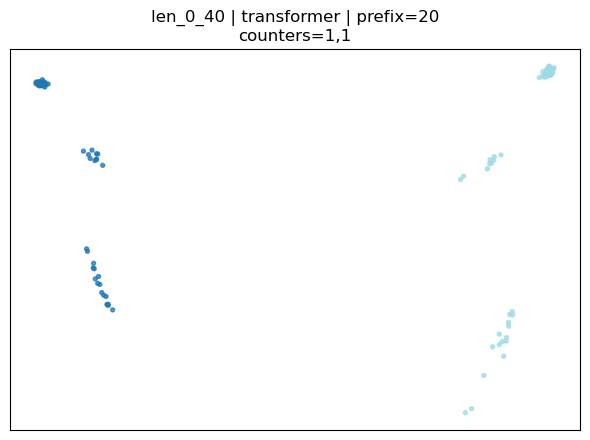

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/pca/len_0_40_mamba_pca.png


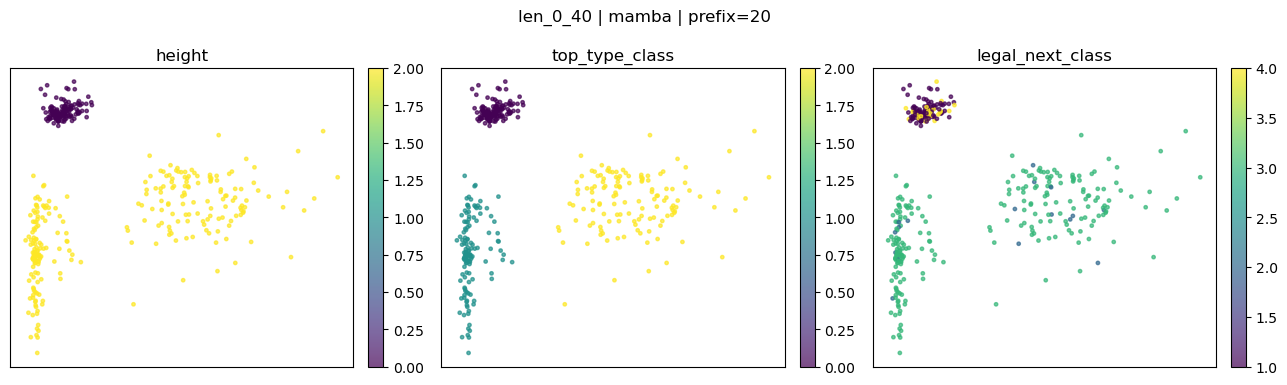

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/stack_slices/len_0_40_mamba_same_counters_diff_stack.png


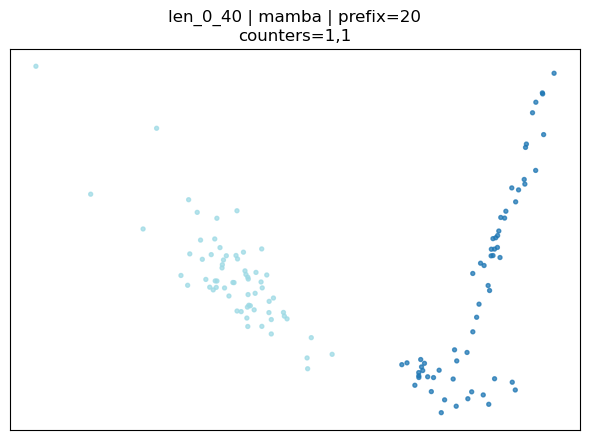

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/pca/len_40_80_rnn_pca.png


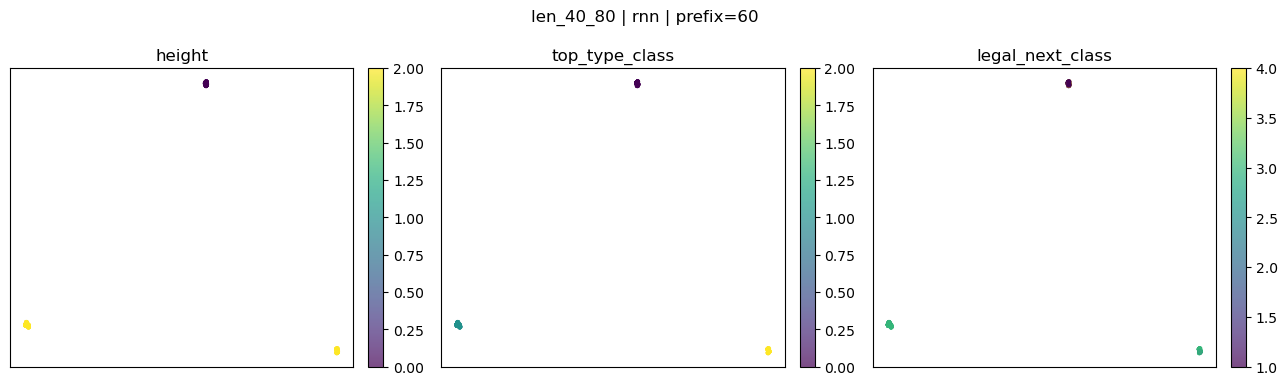

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/stack_slices/len_40_80_rnn_same_counters_diff_stack.png


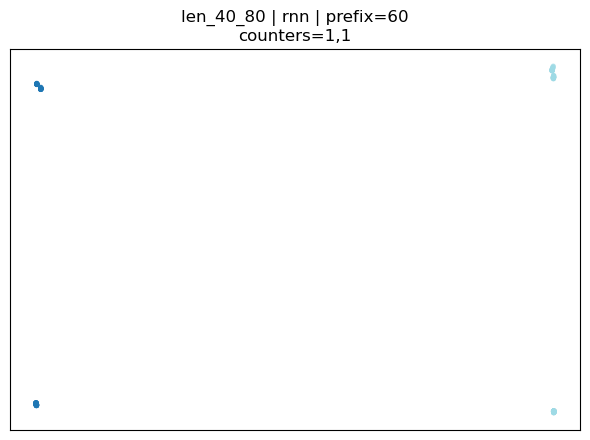

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/pca/len_40_80_lstm_pca.png


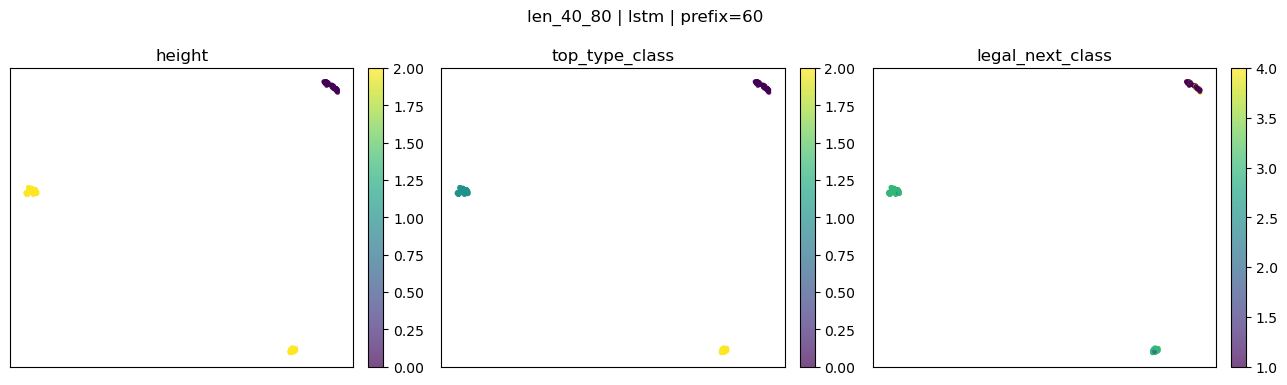

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/stack_slices/len_40_80_lstm_same_counters_diff_stack.png


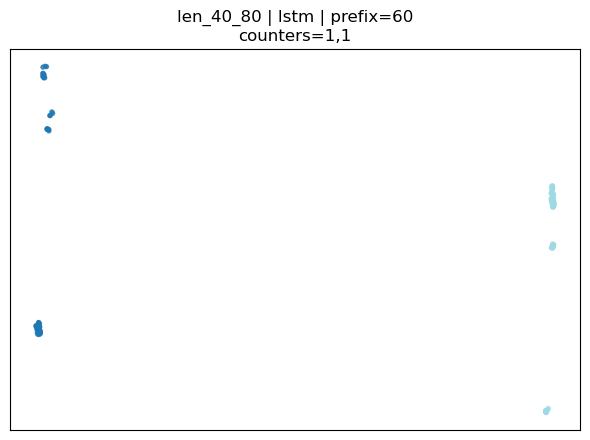

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/pca/len_40_80_transformer_pca.png


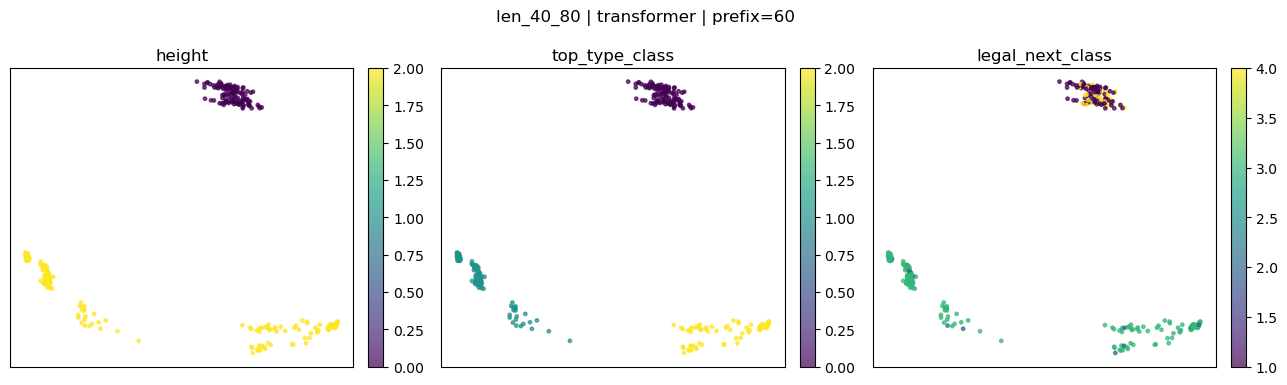

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/stack_slices/len_40_80_transformer_same_counters_diff_stack.png


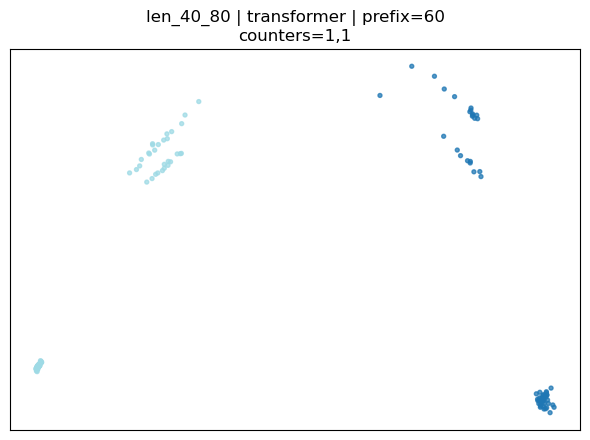

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/pca/len_40_80_mamba_pca.png


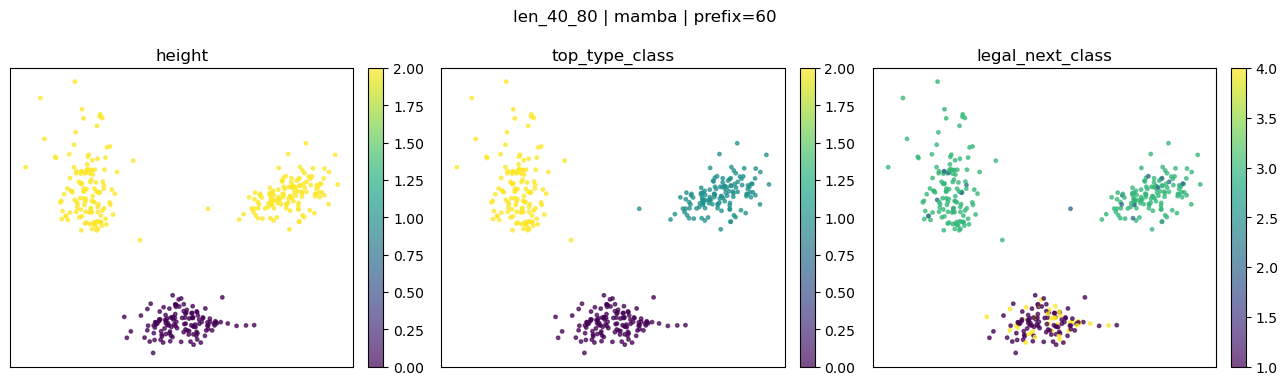

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/stack_slices/len_40_80_mamba_same_counters_diff_stack.png


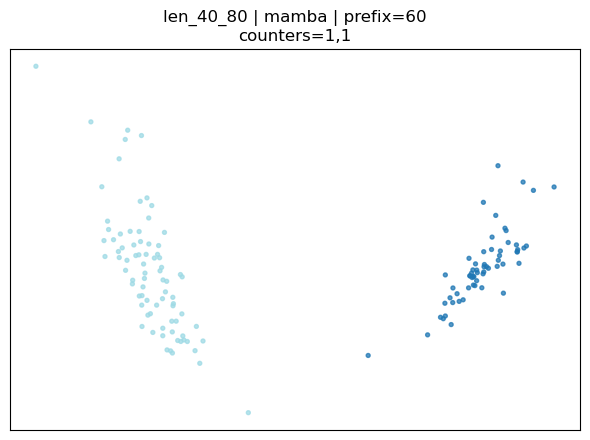

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/pca/len_80_120_rnn_pca.png


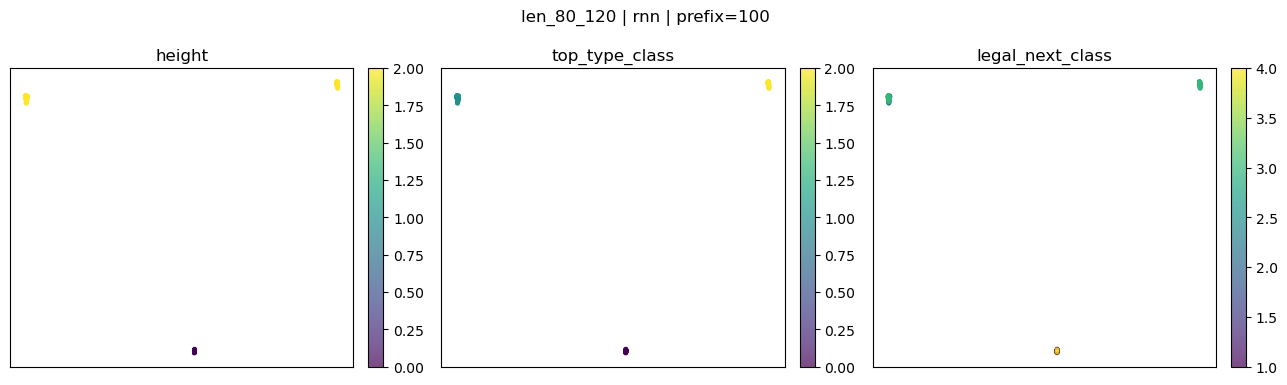

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/stack_slices/len_80_120_rnn_same_counters_diff_stack.png


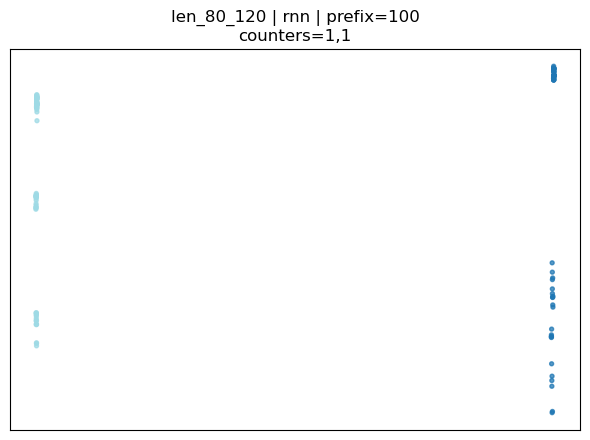

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/pca/len_80_120_lstm_pca.png


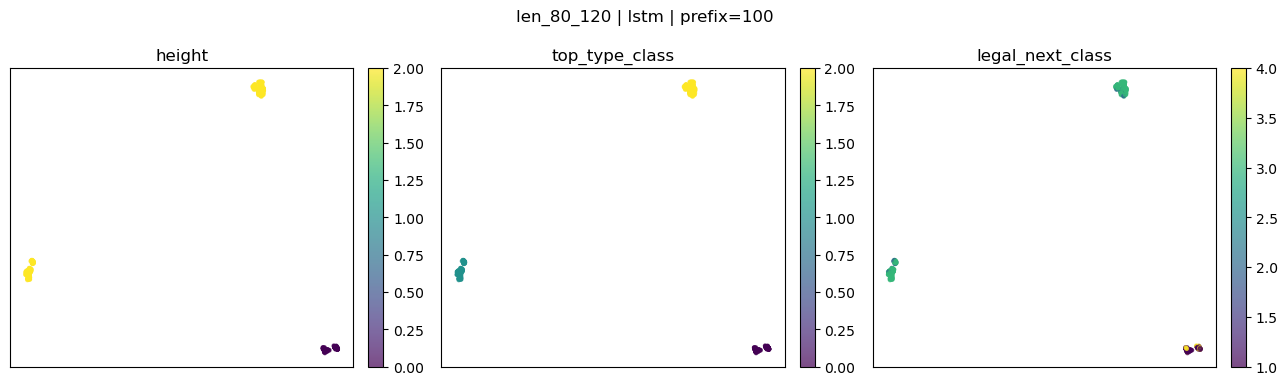

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/stack_slices/len_80_120_lstm_same_counters_diff_stack.png


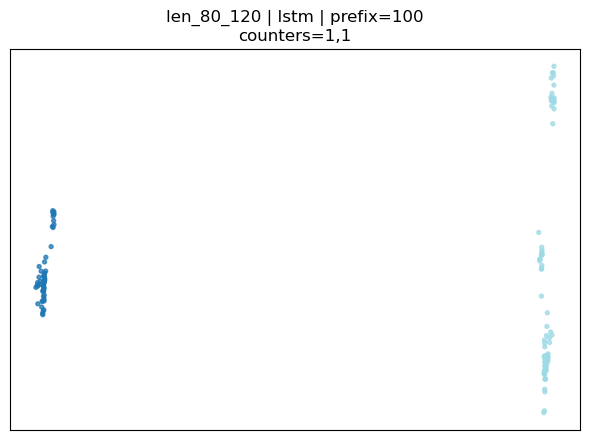

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/pca/len_80_120_transformer_pca.png


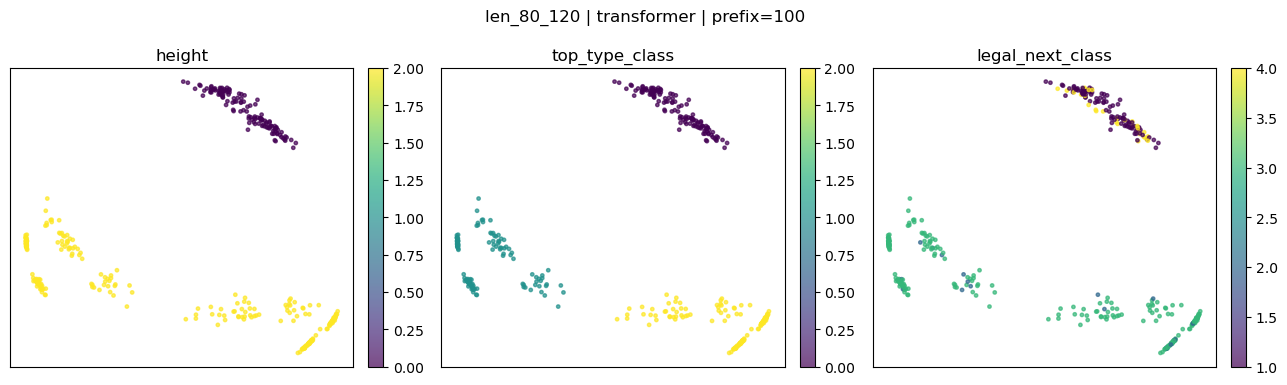

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/stack_slices/len_80_120_transformer_same_counters_diff_stack.png


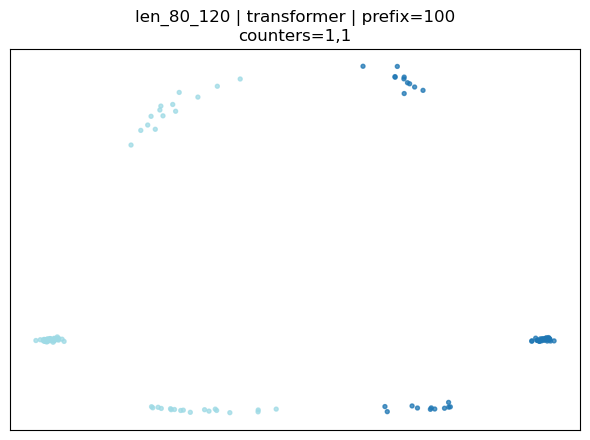

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/pca/len_80_120_mamba_pca.png


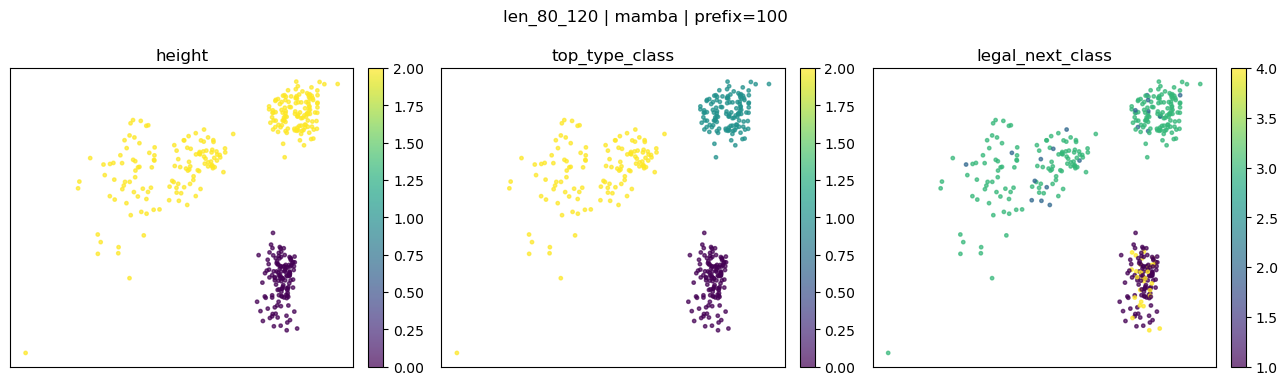

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/stack_slices/len_80_120_mamba_same_counters_diff_stack.png


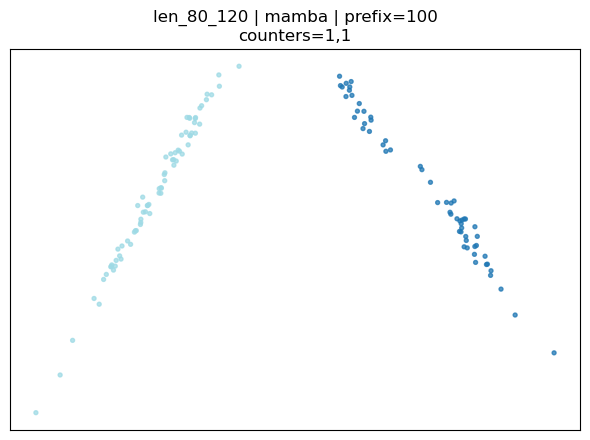

In [6]:
def pca_2d(X):
    X = np.asarray(X, dtype=np.float64)
    X = X - X.mean(axis=0, keepdims=True)
    if PCA is not None:
        return PCA(n_components=2).fit_transform(X)
    _, _, vt = np.linalg.svd(X, full_matrices=False)
    return X @ vt[:2].T


def finalize_figure(fig, section, stem):
    out_dir = FIGURES_ROOT / section
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / f'{stem}.png'
    fig.tight_layout()
    fig.savefig(out_path, dpi=150, bbox_inches='tight')
    print(f'saved figure -> {out_path}')


def plot_depth_counter_pca_panels(result, title, save_stem, max_points=PCA_MAX_POINTS):
    data = result['data']
    labels = data['labels']
    X = data['X']
    if len(labels) > max_points:
        idx = np.random.default_rng(SEED).choice(len(labels), size=max_points, replace=False)
        X = X[idx]
        labels = labels.iloc[idx].reset_index(drop=True)
    Z = pca_2d(X)
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
    for ax, target in zip(axes, ['height', 'top_type_class', 'legal_next_class']):
        vals = labels[target].to_numpy()
        sc = ax.scatter(Z[:, 0], Z[:, 1], c=vals, s=6, cmap='viridis', alpha=0.7)
        ax.set_title(target)
        ax.set_xticks([])
        ax.set_yticks([])
        fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    fig.suptitle(title)
    finalize_figure(fig, 'pca', save_stem)
    plt.show()


def plot_same_counters_diff_stack(result, title, save_stem, max_points_per_stack=200):
    data = result['data']
    labels = data['labels'].copy()
    labels['counter_pair'] = labels['height_round'].astype(str) + ',' + labels['height_square'].astype(str)
    candidates = []
    for counter_pair, group in labels.groupby('counter_pair'):
        if group['stack_repr'].nunique() >= 2 and len(group) >= 20:
            candidates.append((counter_pair, len(group), group['stack_repr'].nunique()))
    if not candidates:
        print('no same-counter/different-stack slice found')
        return
    counter_pair = sorted(candidates, key=lambda x: (x[2], x[1]), reverse=True)[0][0]
    group = labels.loc[labels['counter_pair'] == counter_pair]
    idx = []
    rng = np.random.default_rng(SEED)
    for _, rows in group.groupby('stack_repr'):
        rows_idx = rows.index.to_numpy()
        take = min(len(rows_idx), max_points_per_stack)
        idx.append(rng.choice(rows_idx, size=take, replace=False))
    idx = np.concatenate(idx)
    X = data['X'][idx]
    sub = labels.loc[idx].reset_index(drop=True)
    Z = pca_2d(X)
    codes, names = pd.factorize(sub['stack_repr'])
    fig, ax = plt.subplots(figsize=(6, 4.5))
    sc = ax.scatter(Z[:, 0], Z[:, 1], c=codes, s=8, cmap='tab20', alpha=0.75)
    ax.set_title(f'{title}\ncounters={counter_pair}')
    ax.set_xticks([])
    ax.set_yticks([])
    finalize_figure(fig, 'stack_slices', save_stem)
    plt.show()


for length_bin in DYCK23_LENGTH_BINS:
    for model_type in MODEL_TYPES:
        result = fixed_probe_results[(length_bin, model_type)]
        title = f'{length_bin} | {model_type} | prefix={result["prefix"]}'
        plot_depth_counter_pca_panels(result, title, f'{length_bin}_{model_type}_pca')
        plot_same_counters_diff_stack(result, title, f'{length_bin}_{model_type}_same_counters_diff_stack')


`figures/pca/` 里的 PCA sanity check，以及 `figures/stack_slices/` 里的 same-counter/different-stack slice。

PCA 图按 depth、top type、legal next 上色；stack slice 固定相同 counter，看不同 stack order 是否还能分开。

depth: 最大总嵌套深度，prefix 是偶数，所以只有 0 和 2。

top_type_class: 0 = empty, 1 = round, 2 = square 

legal_next_class: 允许下一步动作集合的编码。

然后固定 height_round = 1, height_square = 1 也就是两个 bracket 类型各有一个未闭合。总 depth 都是 2，所以如果模型只记 counter，这些点应该混在一起。如果分开记录，就应该有比较好的分散情况，按照 stack order 标色，在 counters=1,1 且 total depth=2 的情况下只有两种。

**有意思的地方是，RNN 很容易把这种有限状态任务学成“状态机式表征”，所以 cluster 表示很完美，比其他几个要好很多。**


## 4. Supervised directions and direction heatmaps

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/directions/len_0_40_rnn_direction_heatmap.png


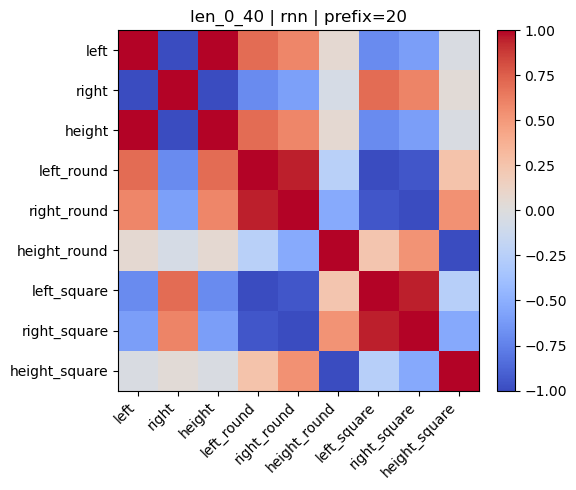

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/supervised_projection/len_0_40_rnn_height_projection.png


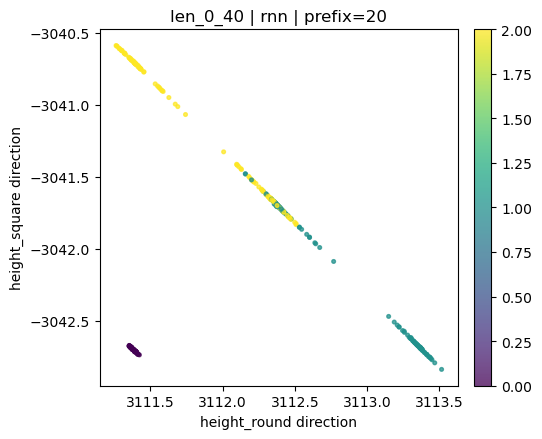

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/directions/len_0_40_lstm_direction_heatmap.png


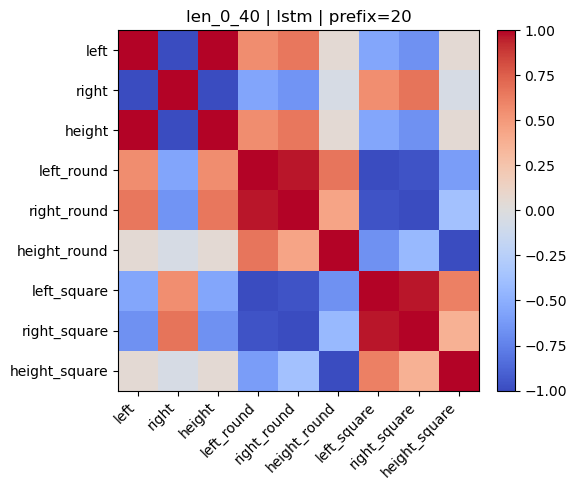

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/supervised_projection/len_0_40_lstm_height_projection.png


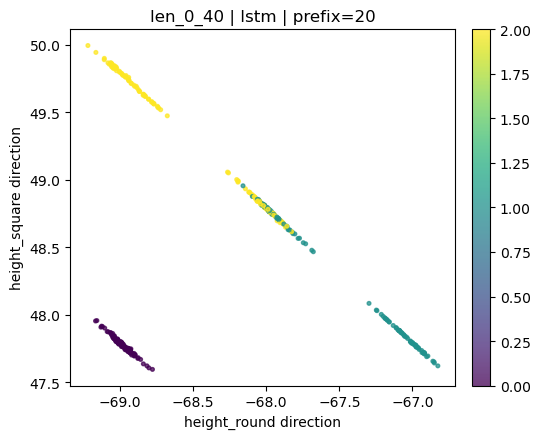

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/directions/len_0_40_transformer_direction_heatmap.png


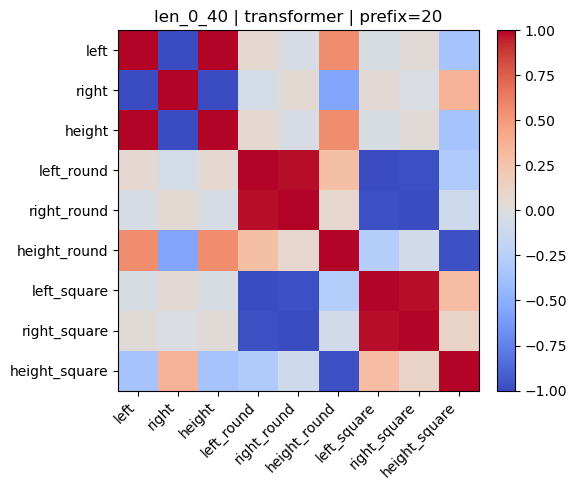

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/supervised_projection/len_0_40_transformer_height_projection.png


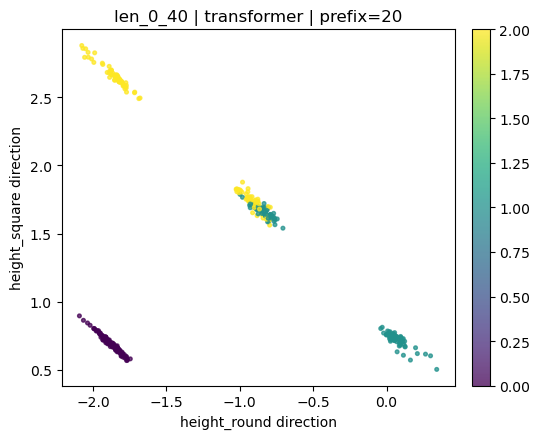

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/directions/len_0_40_mamba_direction_heatmap.png


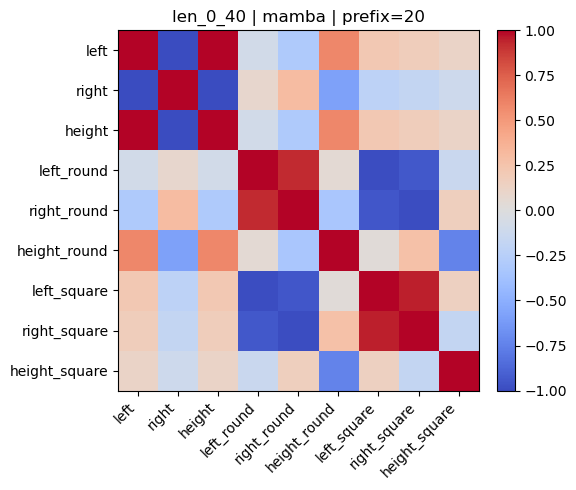

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/supervised_projection/len_0_40_mamba_height_projection.png


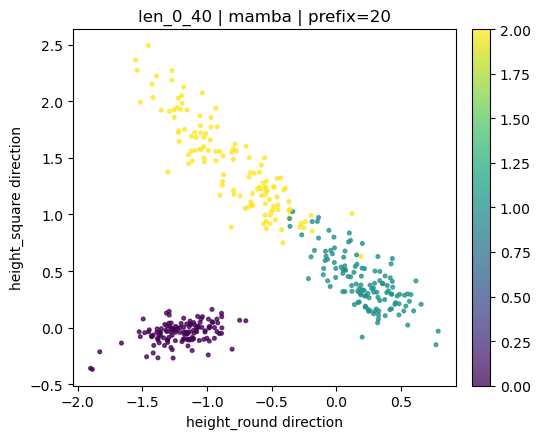

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/directions/len_40_80_rnn_direction_heatmap.png


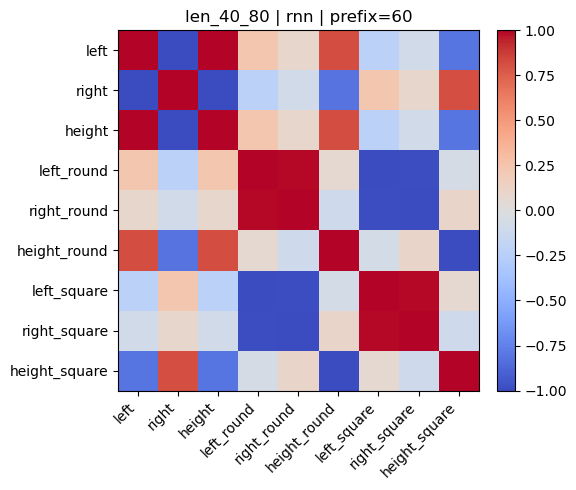

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/supervised_projection/len_40_80_rnn_height_projection.png


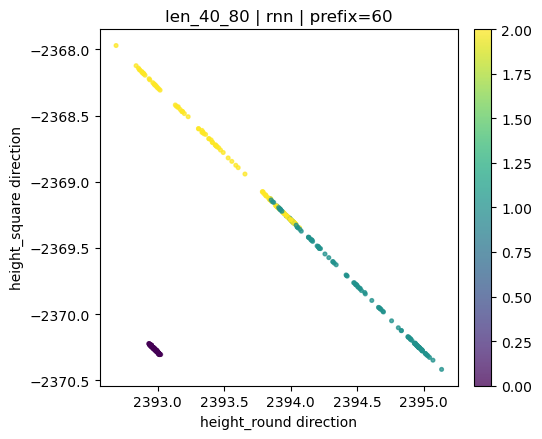

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/directions/len_40_80_lstm_direction_heatmap.png


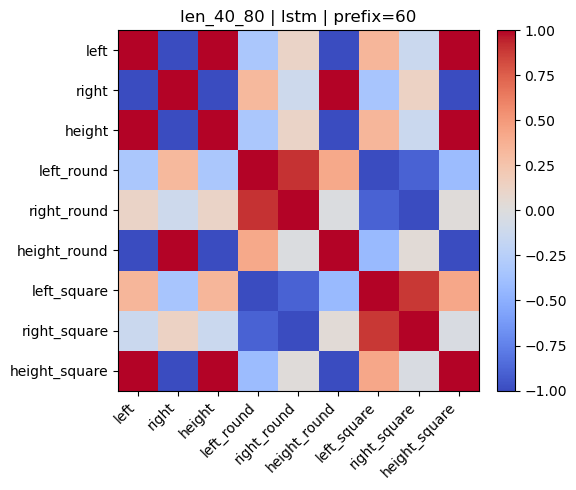

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/supervised_projection/len_40_80_lstm_height_projection.png


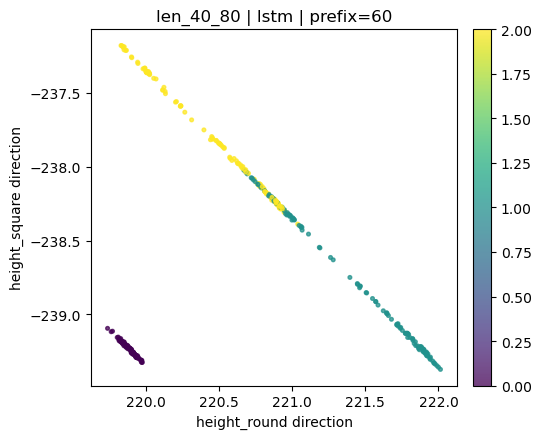

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/directions/len_40_80_transformer_direction_heatmap.png


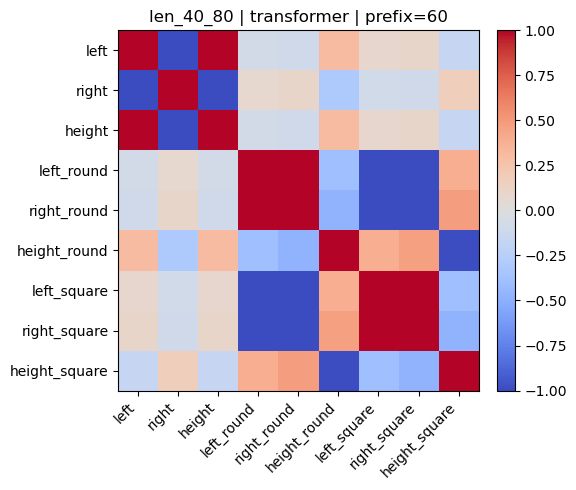

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/supervised_projection/len_40_80_transformer_height_projection.png


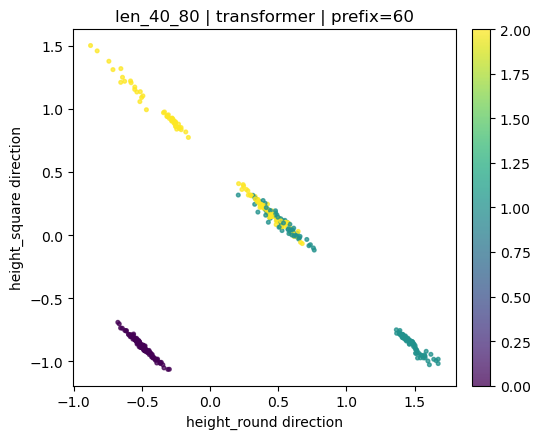

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/directions/len_40_80_mamba_direction_heatmap.png


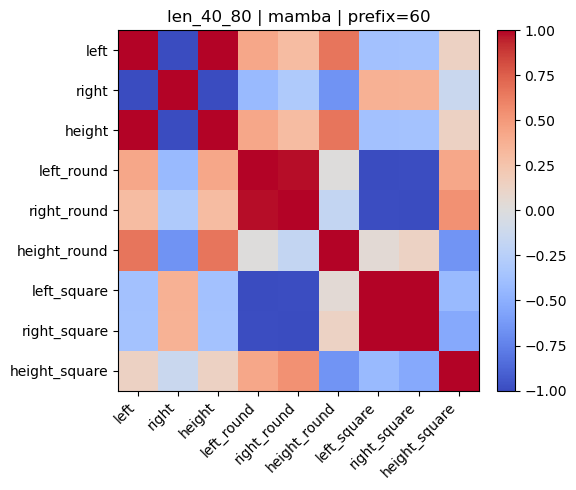

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/supervised_projection/len_40_80_mamba_height_projection.png


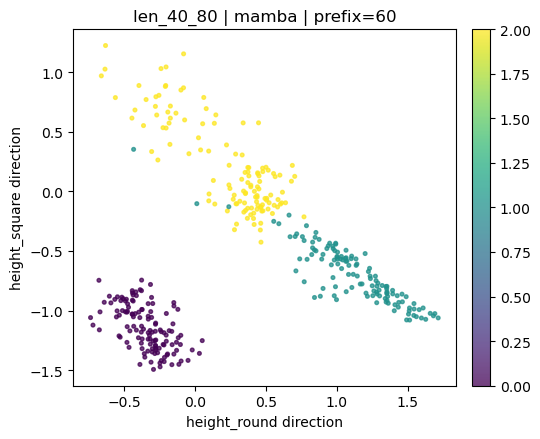

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/directions/len_80_120_rnn_direction_heatmap.png


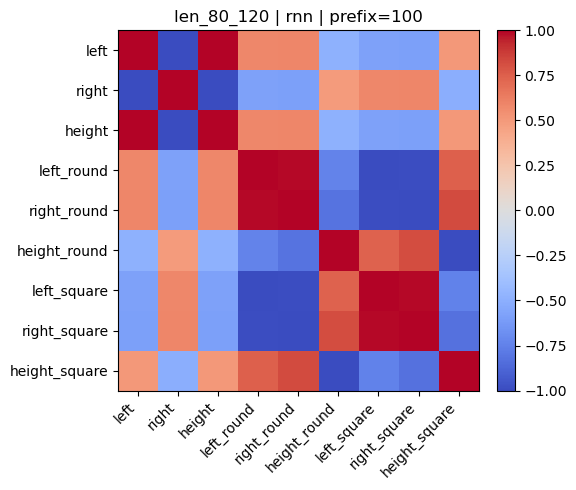

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/supervised_projection/len_80_120_rnn_height_projection.png


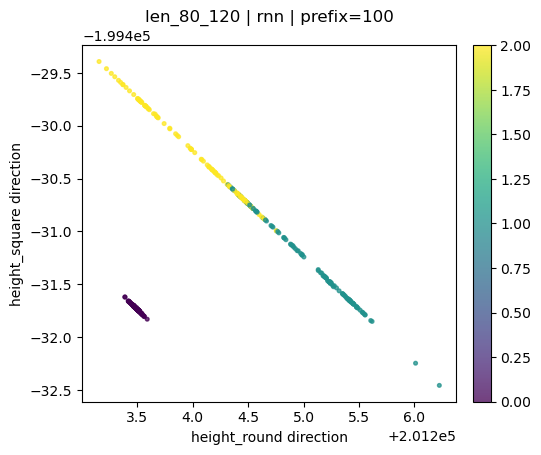

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/directions/len_80_120_lstm_direction_heatmap.png


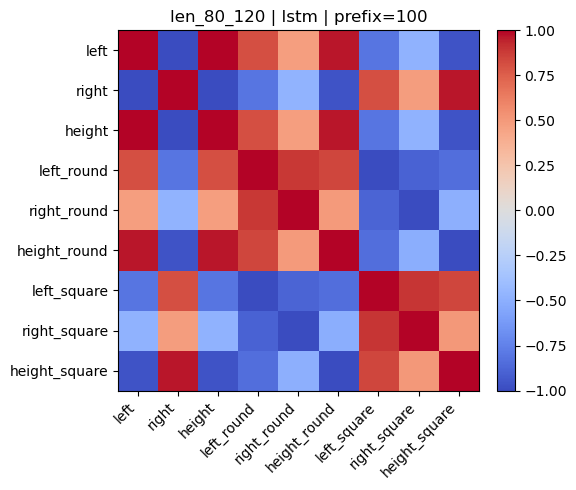

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/supervised_projection/len_80_120_lstm_height_projection.png


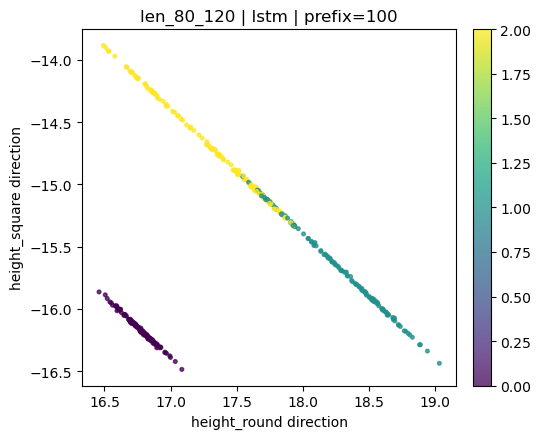

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/directions/len_80_120_transformer_direction_heatmap.png


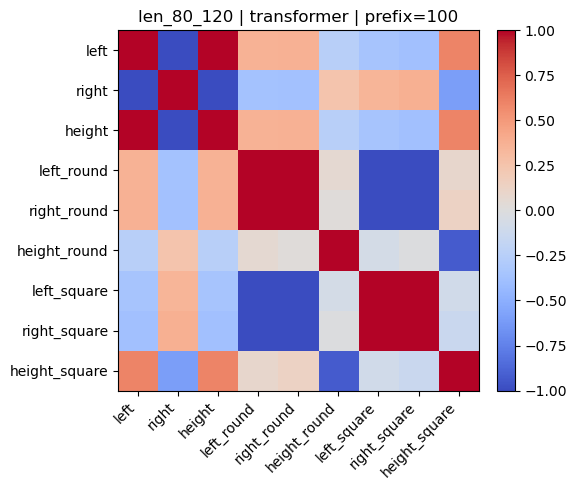

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/supervised_projection/len_80_120_transformer_height_projection.png


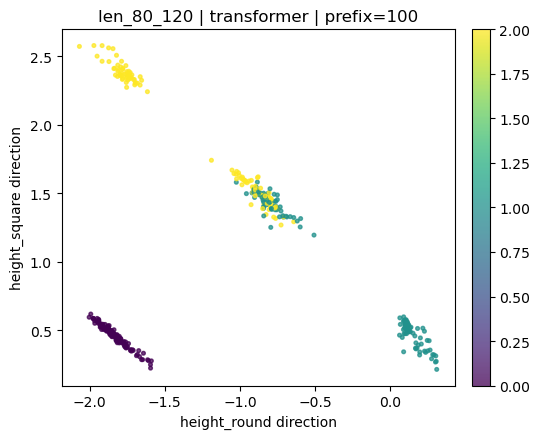

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/directions/len_80_120_mamba_direction_heatmap.png


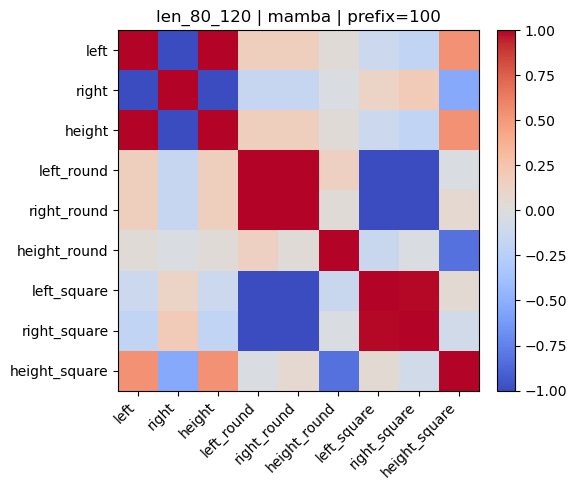

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/supervised_projection/len_80_120_mamba_height_projection.png


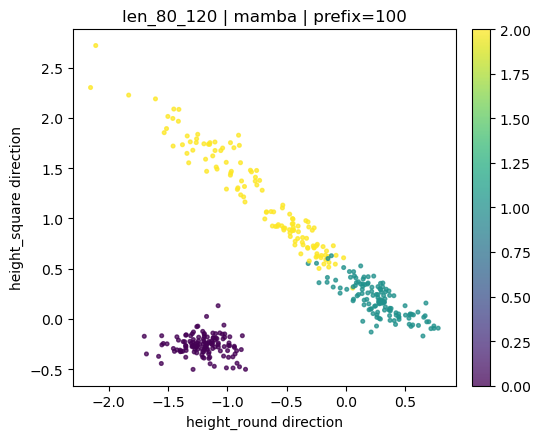

In [7]:
def cosine_matrix(vectors):
    names = list(vectors)
    W = np.stack([vectors[name] for name in names])
    W = W / (np.linalg.norm(W, axis=1, keepdims=True) + 1e-12)
    return names, W @ W.T


def plot_direction_cosine_heatmap(result, title, save_stem):
    fitted = result['fitted']
    vectors = {}
    for key, value in fitted.items():
        if not key.startswith('ridge_'):
            continue
        weight = extract_linear_weight(value['probe'])
        if weight.ndim == 1 and weight.size:
            vectors[key.replace('ridge_', '')] = weight
    if len(vectors) < 2:
        return
    names, C = cosine_matrix(vectors)
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(C, vmin=-1, vmax=1, cmap='coolwarm')
    ax.set_xticks(range(len(names)), names, rotation=45, ha='right')
    ax.set_yticks(range(len(names)), names)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    finalize_figure(fig, 'directions', save_stem)
    plt.show()


def plot_supervised_projection(result, title, save_stem, max_points=PCA_MAX_POINTS):
    data = result['data']
    labels = data['labels']
    X = data['X']
    fitted = result['fitted']
    if len(labels) > max_points:
        idx = np.random.default_rng(SEED).choice(len(labels), size=max_points, replace=False)
        X = X[idx]
        labels = labels.iloc[idx].reset_index(drop=True)
    wx = extract_linear_weight(fitted['ridge_height_round']['probe'])
    wy = extract_linear_weight(fitted['ridge_height_square']['probe'])
    Z = np.stack([X @ wx, X @ wy], axis=1)
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    sc = ax.scatter(Z[:, 0], Z[:, 1], c=labels['top_type_class'], s=7, cmap='viridis', alpha=0.75)
    ax.set_xlabel('height_round direction')
    ax.set_ylabel('height_square direction')
    ax.set_title(title)
    fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    finalize_figure(fig, 'supervised_projection', save_stem)
    plt.show()


for length_bin in DYCK23_LENGTH_BINS:
    for model_type in MODEL_TYPES:
        result = fixed_probe_results[(length_bin, model_type)]
        title = f'{length_bin} | {model_type} | prefix={result["prefix"]}'
        plot_direction_cosine_heatmap(result, title, f'{length_bin}_{model_type}_direction_heatmap')
        plot_supervised_projection(result, title, f'{length_bin}_{model_type}_height_projection')


这个 cell 生成 `figures/directions/` 的 direction cosine heatmap，以及 `figures/supervised_projection/` 的两个 supervised counter direction 投影图。heatmap 看不同 probe direction 是否对齐/相反/接近正交；projection 图把 hidden state 投到两个 per-type height 方向上。

cosine 接近 1 表示两个读出方向几乎同向，接近 -1 表示近似反向，接近 0 表示更正交。projection 图里如果点贴近整数格点，说明对应 counter 可以被线性读出，并且状态空间呈现 Dyck 合法 lattice。

Transformer 更像用 total depth 和 round-square type contrast 来组织表征。left 和 height 几乎同向，right 和它们反向。原始 round/square counter directions 不是彼此正交，而更像 total-depth + type-contrast 的坐标系。


## 5. All-prefix counter lattice views

Fixed-prefix projections are intentionally controlled, but Dyck-(2,3) has a depth parity constraint at a single prefix. These all-prefix views balance by `(height_round, height_square)` and refit just those two counter probes, making the available integer lattice points easier to see.


saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/counter_lattices/len_0_40_rnn_height_round_vs_height_square_all_prefixes.png


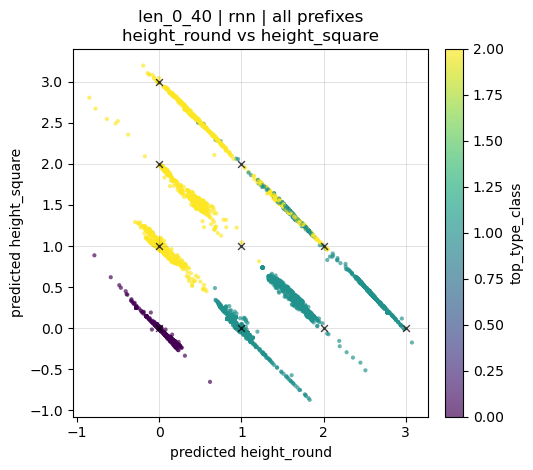

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/counter_lattices/len_0_40_lstm_height_round_vs_height_square_all_prefixes.png


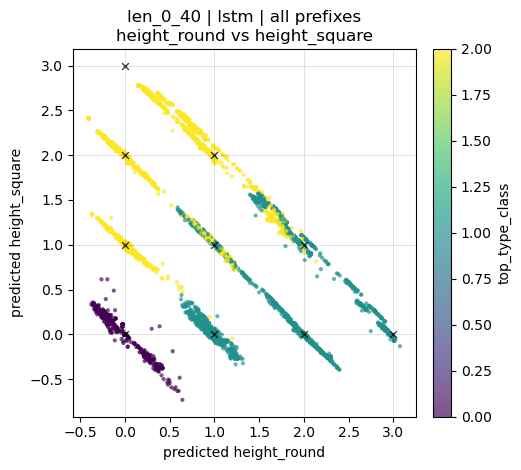

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/counter_lattices/len_0_40_transformer_height_round_vs_height_square_all_prefixes.png


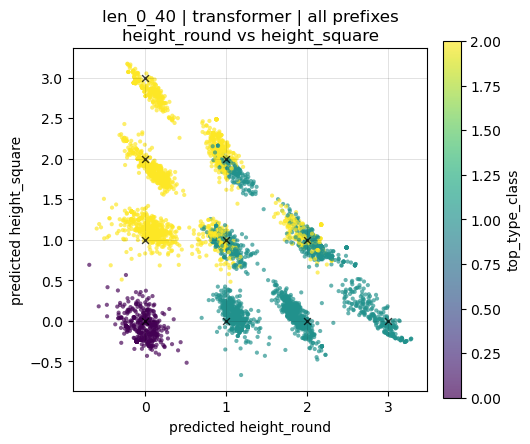

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/counter_lattices/len_0_40_mamba_height_round_vs_height_square_all_prefixes.png


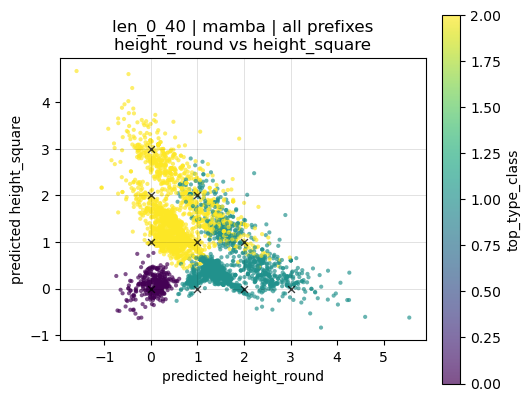

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/counter_lattices/len_40_80_rnn_height_round_vs_height_square_all_prefixes.png


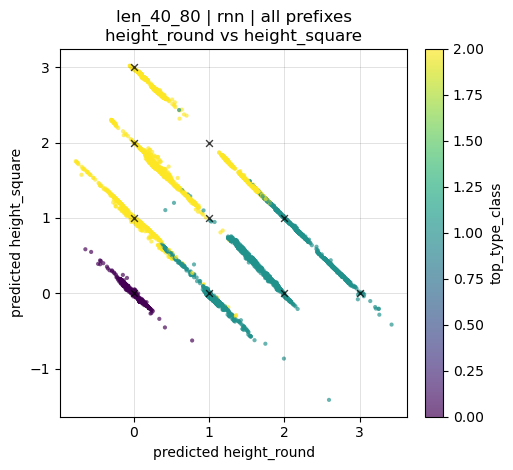

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/counter_lattices/len_40_80_lstm_height_round_vs_height_square_all_prefixes.png


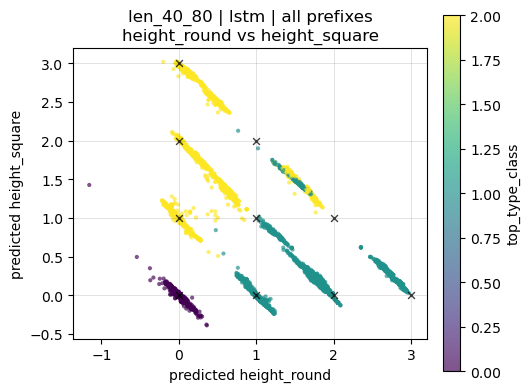

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/counter_lattices/len_40_80_transformer_height_round_vs_height_square_all_prefixes.png


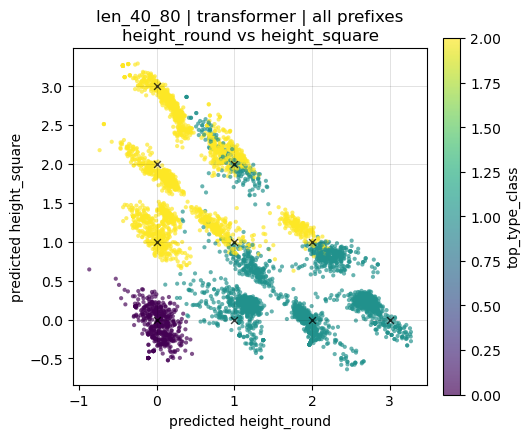

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/counter_lattices/len_40_80_mamba_height_round_vs_height_square_all_prefixes.png


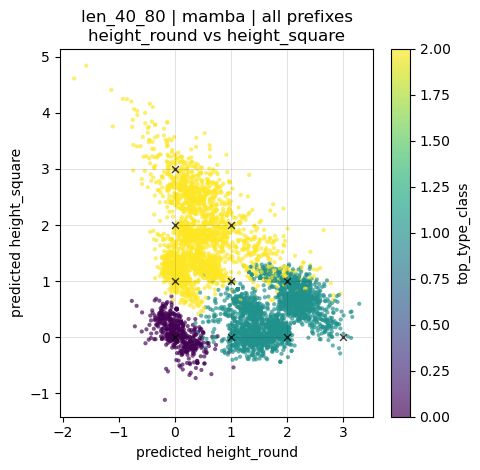

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/counter_lattices/len_80_120_rnn_height_round_vs_height_square_all_prefixes.png


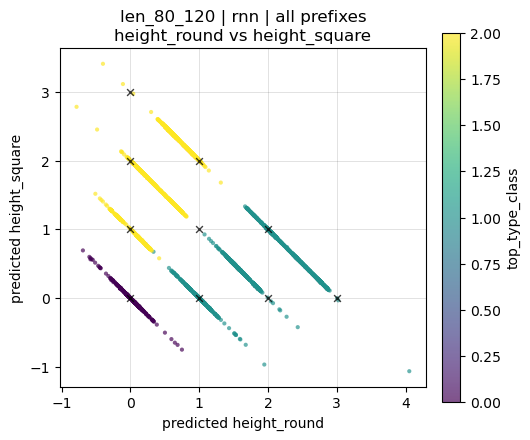

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/counter_lattices/len_80_120_lstm_height_round_vs_height_square_all_prefixes.png


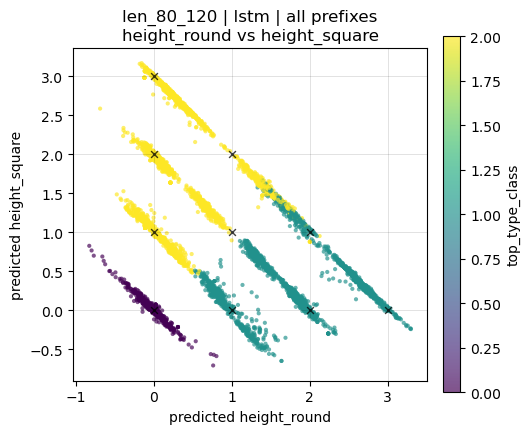

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/counter_lattices/len_80_120_transformer_height_round_vs_height_square_all_prefixes.png


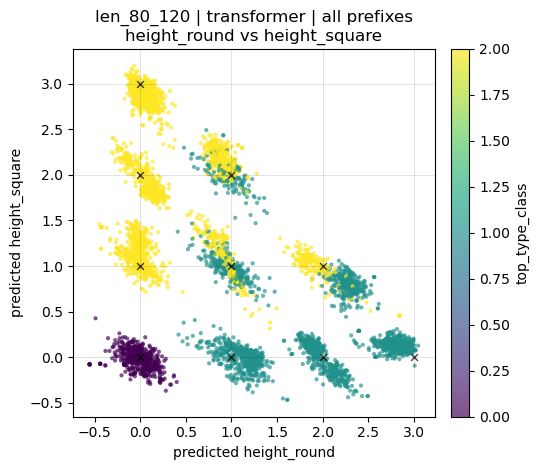

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/counter_lattices/len_80_120_mamba_height_round_vs_height_square_all_prefixes.png


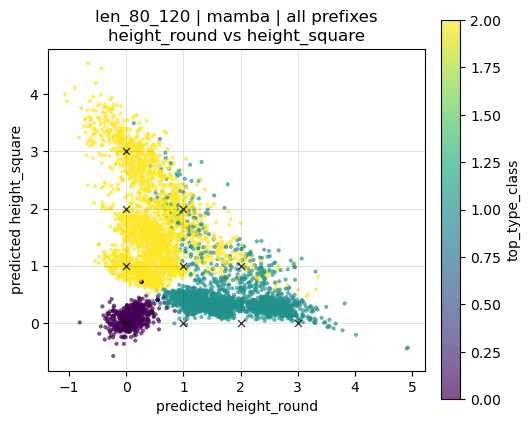

,length_bin,model,prefix,x_target,y_target,x_mae_to_integer,y_mae_to_integer,joint_round_exact,n_grid_points,n
0,len_0_40,rnn,all,height_round,height_square,0.280829,0.280447,0.836254,10,4623
1,len_0_40,lstm,all,height_round,height_square,0.189525,0.188114,0.944625,10,4623
2,len_0_40,transformer,all,height_round,height_square,0.136379,0.140665,0.987238,10,4623
3,len_0_40,mamba,all,height_round,height_square,0.363785,0.325981,0.623405,10,4623
4,len_40_80,rnn,all,height_round,height_square,0.298910,0.297872,0.825195,10,5120
5,len_40_80,lstm,all,height_round,height_square,0.251306,0.250597,0.849805,10,5120
6,len_40_80,transformer,all,height_round,height_square,0.191347,0.198064,0.951758,10,5120
7,len_40_80,mamba,all,height_round,height_square,0.373485,0.349976,0.613867,10,5120
8,len_80_120,rnn,all,height_round,height_square,0.371169,0.370991,0.668945,10,5120
9,len_80_120,lstm,all,height_round,height_square,0.278369,0.279082,0.834961,10,5120


In [9]:
def balance_data_by_counter_pair(data, x_target='height_round', y_target='height_square', seed=0, max_per_pair=512, min_per_pair=8):
    labels = data['labels']
    rng = np.random.default_rng(seed)
    chosen = []
    for _, idx in labels.groupby([x_target, y_target]).indices.items():
        idx = np.asarray(idx)
        if len(idx) < min_per_pair:
            continue
        take = min(len(idx), max_per_pair)
        chosen.append(rng.choice(idx, size=take, replace=False))
    if not chosen:
        return data
    chosen = np.sort(np.concatenate(chosen))
    return {'X': data['X'][chosen], 'labels': labels.iloc[chosen].reset_index(drop=True), 'run_dir': data['run_dir']}


def fit_counter_pair_result(data, x_target='height_round', y_target='height_square', seed=0):
    X = data['X']
    labels = data['labels']
    train_idx, test_idx = _split_indices(len(labels), seed=seed)
    fitted = {}
    for target in [x_target, y_target, 'height']:
        if target not in labels:
            continue
        fitted[f'ridge_{target}'] = fit_ridge_train_test(
            X[train_idx],
            labels[target].to_numpy()[train_idx],
            X[test_idx],
            labels[target].to_numpy()[test_idx],
            target,
        )
    return {'data': data, 'fitted': fitted, 'table': pd.DataFrame(), 'prefix': 'all'}


lattice_rows = []
for length_bin in DYCK23_LENGTH_BINS:
    for model_type in MODEL_TYPES:
        raw = run_arrays[(length_bin, model_type)]
        data = balance_data_by_counter_pair(raw, seed=SEED)
        result = fit_counter_pair_result(data, seed=SEED)
        base = {'length_bin': length_bin, 'model': model_type, 'prefix': 'all'}
        for row in counter_grid_scores(result, target_pairs=[('height_round', 'height_square')]):
            lattice_rows.append({**base, **row})
        plot_counter_grid_projection(
            result,
            f'{length_bin} | {model_type} | all prefixes\nheight_round vs height_square',
            f'{length_bin}_{model_type}_height_round_vs_height_square_all_prefixes',
            x_target='height_round',
            y_target='height_square',
            max_points=7_000,
            section='counter_lattices',
        )

counter_lattice_df = pd.DataFrame(lattice_rows)
counter_lattice_df.to_csv(RESULTS_ROOT / 'counter_lattice_summary.csv', index=False)
counter_lattice_df


做 all-prefix counter lattice：把所有 prefix 的 hidden state 按 `(height_round, height_square)` 平衡采样，再拟合两个 counter direction，并生成 `counter_lattice_summary.csv` 和 `figures/counter_lattices/` 下的 lattice scatter。

Dyck-(2,3) 的合法状态满足 `height_round >= 0`、`height_square >= 0`、`height_round + height_square <= 3`，所以应该看到三角形格点，而不是矩形网格。格点越紧、`joint_round_exact` 越高，counter 表征越清楚。

- x = ridge probe 预测的 height_round
- y = ridge probe 预测的 height_square
- 颜色 = top_type_class
- 0 紫色: empty
- 1 青色: top round
- 2 黄色: top square
- 黑色 x: 真实合法整数格点

Transformer / LSTM / RNN 都形成了比较明确的 Dyck counter lattice；Mamba 有 lattice 趋势，但更连续、更噪。

## 6. Prefix sweep

In [10]:
def run_prefix_sweep_for_run(length_bin, model_type):
    rows = []
    directions = {}
    raw = run_arrays[(length_bin, model_type)]
    for prefix in SWEEP_PREFIX_BY_BIN[length_bin]:
        data = balance_data_by_label(select_prefix(raw, prefix), seed=SEED)
        if len(data['labels']) < 32:
            continue
        fitted, table = run_stack_probes(data, seed=SEED)
        lookup = {(r.probe_type, r.target): r for r in table.itertuples()}
        row = {'length_bin': length_bin, 'model': model_type, 'prefix': prefix, 'n': len(data['labels'])}
        for target in ['height', 'height_round', 'height_square']:
            key = ('ridge', target)
            if key in lookup:
                row[f'{target}_r2'] = lookup[key].r2
        for target in ['top_type_class', 'depth_top_class', 'legal_next_class']:
            key = ('logistic', target)
            if key in lookup:
                row[f'{target}_accuracy'] = lookup[key].accuracy
        rows.append(row)
        direction_row = {}
        for target in RIDGE_TARGETS:
            probe = fitted.get(f'ridge_{target}')
            if probe:
                direction_row[target] = extract_linear_weight(probe['probe'])
        directions[prefix] = direction_row
    return {'rows': pd.DataFrame(rows), 'directions': directions}


prefix_sweep_results = {}
for length_bin in DYCK23_LENGTH_BINS:
    for model_type in MODEL_TYPES:
        print(f'prefix sweep: {length_bin} {model_type}')
        prefix_sweep_results[(length_bin, model_type)] = run_prefix_sweep_for_run(length_bin, model_type)

prefix_sweep_df = pd.concat([v['rows'] for v in prefix_sweep_results.values()], ignore_index=True)
prefix_sweep_df.to_csv(RESULTS_ROOT / 'prefix_sweep_summary.csv', index=False)
prefix_sweep_df


prefix sweep: len_0_40 rnn


prefix sweep: len_0_40 lstm


prefix sweep: len_0_40 transformer


prefix sweep: len_0_40 mamba


prefix sweep: len_40_80 rnn


...

prefix sweep: len_80_120 rnn


prefix sweep: len_80_120 lstm


prefix sweep: len_80_120 transformer


prefix sweep: len_80_120 mamba


,length_bin,model,prefix,n,height_r2,height_round_r2,height_square_r2,top_type_class_accuracy,depth_top_class_accuracy,legal_next_class_accuracy
0,len_0_40,rnn,4,384,0.999993,0.991126,0.991676,1.0,1.0,0.885417
1,len_0_40,rnn,8,384,0.999989,0.971100,0.971030,1.0,1.0,0.854167
2,len_0_40,rnn,12,384,0.999991,0.971441,0.966848,1.0,1.0,0.885417
3,len_0_40,rnn,16,384,0.999989,0.968779,0.973823,1.0,1.0,0.854167
4,len_0_40,rnn,20,384,0.999992,0.989375,0.989063,1.0,1.0,0.802083
...,...,...,...,...,...,...,...,...,...,...
115,len_80_120,mamba,104,382,0.961489,0.849710,0.857471,1.0,1.0,0.770833
116,len_80_120,mamba,108,342,0.970961,0.830206,0.878460,1.0,1.0,0.709302
117,len_80_120,mamba,112,257,0.973153,0.844749,0.847315,1.0,1.0,0.625000
118,len_80_120,mamba,116,162,0.953436,0.828562,0.897704,1.0,1.0,0.575000


这个 cell 做 prefix sweep：沿每个长度桶的一系列 prefix 位置重复筛样本、平衡类别、拟合 probe，并保存 `prefix_sweep_summary.csv`。它本身主要产出表，不画最终 sweep 图。

表里的每一行是一个模型在某个长度桶、某个 prefix 的 probe 表现。关注 `height_r2`、`top_type_class_accuracy`、`legal_next_class_accuracy` 随 prefix 的变化，可以判断模型是在序列早期还是中后期形成可读出的栈状态。


saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/sweeps/prefix_sweep.png


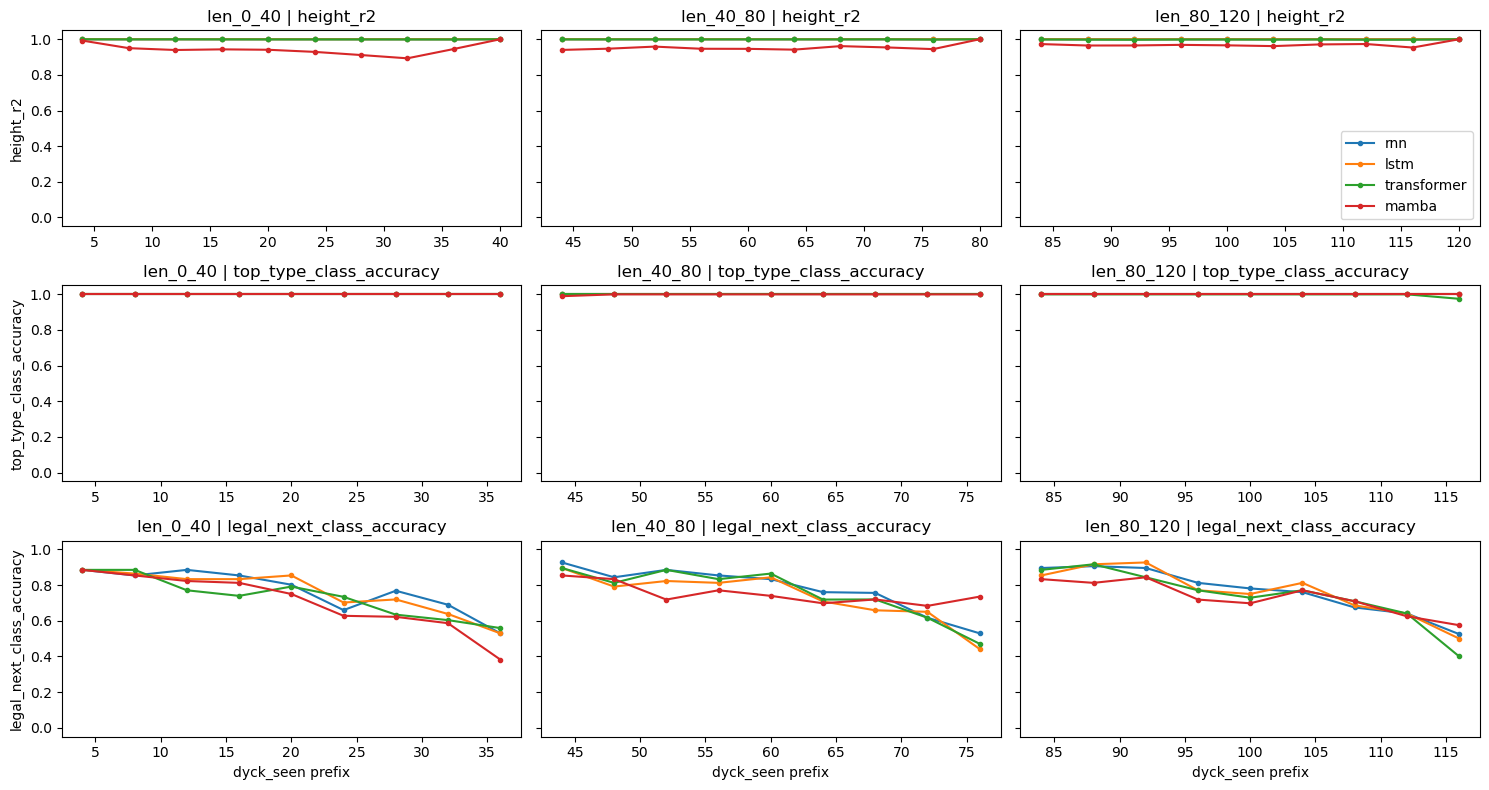

In [11]:
def plot_prefix_sweep(df):
    metrics = ['height_r2', 'top_type_class_accuracy', 'legal_next_class_accuracy']
    fig, axes = plt.subplots(len(metrics), len(DYCK23_LENGTH_BINS), figsize=(15, 8), sharex=False, sharey='row')
    for col, length_bin in enumerate(DYCK23_LENGTH_BINS):
        sub_bin = df.loc[df['length_bin'] == length_bin]
        for row, metric in enumerate(metrics):
            ax = axes[row, col]
            for model_type in MODEL_TYPES:
                sub = sub_bin.loc[sub_bin['model'] == model_type]
                if metric in sub:
                    ax.plot(sub['prefix'], sub[metric], marker='o', ms=3, label=model_type)
            ax.set_title(f'{length_bin} | {metric}')
            ax.set_ylim(-0.05, 1.05)
            if row == len(metrics) - 1:
                ax.set_xlabel('dyck_seen prefix')
            if col == 0:
                ax.set_ylabel(metric)
            if row == 0 and col == len(DYCK23_LENGTH_BINS) - 1:
                ax.legend(loc='lower right')
    finalize_figure(fig, 'sweeps', 'prefix_sweep')
    plt.show()


plot_prefix_sweep(prefix_sweep_df)


把 prefix sweep 表画成 `figures/sweeps/prefix_sweep.png`。三行分别展示 height 可读性、top type 可读性、legal-next 可读性；三列对应三个长度桶。

曲线越接近 1，说明该变量越容易从 hidden state 线性/逻辑读出。若某模型在长桶后段掉得明显，说明它对长序列状态维护更弱；若各长度桶都稳定，说明该表征比较一致。

所有模型都学到了核心 Dyck stack state：depth + top type

但它们对 CFG 长度预算/终止条件的线性可读性明显弱很多：legal_next_class 随 prefix 后移而下降

## 7. Direction arithmetic

In [12]:
def cosine(a, b):
    a = np.asarray(a)
    b = np.asarray(b)
    return float(a @ b / ((np.linalg.norm(a) + 1e-12) * (np.linalg.norm(b) + 1e-12)))


def _counter_pair_column(x_target, y_target):
    return f'cos_{x_target}_{y_target}'


def direction_arithmetic_table(prefix_sweep_results):
    rows = []
    for (length_bin, model_type), result in prefix_sweep_results.items():
        for prefix, directions in result['directions'].items():
            if not {'height', 'height_round', 'height_square'}.issubset(directions):
                continue
            summed = directions['height_round'] + directions['height_square']
            row = {
                'length_bin': length_bin,
                'model': model_type,
                'prefix': prefix,
                'cos_height_round': cosine(directions['height'], directions['height_round']),
                'cos_height_square': cosine(directions['height'], directions['height_square']),
                'cos_round_square': cosine(directions['height_round'], directions['height_square']),
                'cos_height_sum': cosine(directions['height'], summed),
            }
            for x_target, y_target in COUNTER_TARGET_PAIRS:
                if x_target in directions and y_target in directions:
                    pair_col = _counter_pair_column(x_target, y_target)
                    wx = directions[x_target]
                    wy = directions[y_target]
                    w_sum = wx + wy
                    w_diff = wx - wy
                    row[pair_col] = cosine(wx, wy)
                    row[f'{pair_col}_sum_diff'] = cosine(w_sum, w_diff)
                    total_target = COUNTER_TOTAL_TARGETS.get((x_target, y_target))
                    if total_target in directions:
                        wt = directions[total_target]
                        row[f'{pair_col}_total_sum'] = cosine(wt, w_sum)
                        row[f'{pair_col}_total_diff'] = cosine(wt, w_diff)
            rows.append(row)
    return pd.DataFrame(rows)


direction_arithmetic_df = direction_arithmetic_table(prefix_sweep_results)
direction_arithmetic_df.to_csv(RESULTS_ROOT / 'direction_arithmetic_summary.csv', index=False)
direction_arithmetic_df


,length_bin,model,prefix,cos_height_round,cos_height_square,cos_round_square,cos_height_sum,cos_height_round_height_square,cos_height_round_height_square_sum_diff,cos_height_round_height_square_total_sum,cos_height_round_height_square_total_diff,cos_left_round_left_square,cos_left_round_left_square_sum_diff,cos_left_round_left_square_total_sum,cos_left_round_left_square_total_diff,cos_right_round_right_square,cos_right_round_right_square_sum_diff,cos_right_round_right_square_total_sum,cos_right_round_right_square_total_diff
0,len_0_40,rnn,4,0.318424,-0.292685,-0.999635,1.0,-0.999635,0.305638,1.0,0.305638,-0.999960,0.603477,1.000000,0.603477,-0.999965,-0.282092,1.000000,-0.282092
1,len_0_40,rnn,8,0.404576,-0.384986,-0.999773,1.0,-0.999773,0.394849,1.0,0.394849,-0.999979,-0.430396,1.000000,-0.430396,-0.999989,0.492918,1.000000,0.492918
2,len_0_40,rnn,12,0.560862,-0.547653,-0.999874,1.0,-0.999874,0.554310,1.0,0.554310,-0.999990,-0.421231,1.000000,-0.421231,-0.999994,0.611336,1.000000,0.611336
3,len_0_40,rnn,16,0.298683,-0.282850,-0.999863,1.0,-0.999863,0.290796,1.0,0.290796,-0.999992,0.678344,1.000000,0.678344,-0.999985,-0.680407,1.000000,-0.680407
4,len_0_40,rnn,20,0.056129,-0.035508,-0.999787,1.0,-0.999787,0.045826,1.0,0.045826,-0.999996,0.696689,1.000000,0.696689,-0.999997,-0.594014,1.000000,-0.594014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,len_80_120,mamba,104,0.262951,0.524805,-0.683269,1.0,-0.683269,-0.169506,1.0,-0.169506,-0.999148,0.291215,1.000000,0.291215,-0.999133,-0.312849,1.000000,-0.312849
116,len_80_120,mamba,108,0.515200,0.389016,-0.589139,1.0,-0.589139,0.089065,1.0,0.089065,-0.999470,0.142818,1.000000,0.142818,-0.999467,-0.137369,1.000000,-0.137369
117,len_80_120,mamba,112,0.405448,0.485211,-0.602574,1.0,-0.602574,-0.055598,1.0,-0.055598,-0.999366,-0.255073,1.000000,-0.255073,-0.999335,0.257196,1.000000,0.257196
118,len_80_120,mamba,116,0.425889,0.362174,-0.689105,1.0,-0.689105,0.041045,1.0,0.041045,-0.999548,0.107700,1.000000,0.107700,-0.999540,-0.105714,1.000000,-0.105714


计算 direction arithmetic，并保存 `direction_arithmetic_summary.csv`。核心问题是：`height` direction 是否接近 `height_round + height_square`，以及 raw per-type directions、sum/diff basis 在 prefix sweep 中怎样变化。

`cos_height_sum` 接近 1 表示总 depth 的读出方向基本等于两类 per-type height direction 的和。`cos_*_sum_diff` 的绝对值越接近 0，说明 sum 轴和 diff 轴越接近正交，也就是模型更像在用“总深度 + 类型差异”的坐标系。


saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/sweeps/direction_arithmetic.png


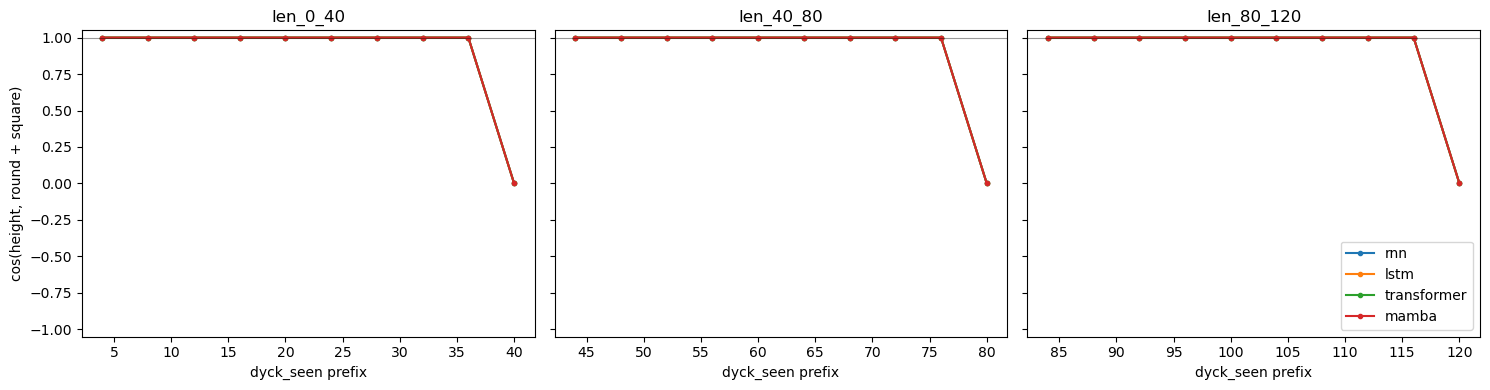

In [13]:
def plot_direction_arithmetic(df):
    fig, axes = plt.subplots(1, len(DYCK23_LENGTH_BINS), figsize=(15, 4), sharey=True)
    for ax, length_bin in zip(axes, DYCK23_LENGTH_BINS):
        sub_bin = df.loc[df['length_bin'] == length_bin]
        for model_type in MODEL_TYPES:
            sub = sub_bin.loc[sub_bin['model'] == model_type]
            ax.plot(sub['prefix'], sub['cos_height_sum'], marker='o', ms=3, label=model_type)
        ax.axhline(1.0, color='black', lw=0.8, alpha=0.4)
        ax.set_title(length_bin)
        ax.set_xlabel('dyck_seen prefix')
        ax.set_ylim(-1.05, 1.05)
    axes[0].set_ylabel('cos(height, round + square)')
    axes[-1].legend(loc='lower right')
    finalize_figure(fig, 'sweeps', 'direction_arithmetic')
    plt.show()


plot_direction_arithmetic(direction_arithmetic_df)


 `figures/sweeps/direction_arithmetic.png`，展示不同模型、不同长度桶里 `cos(height, height_round + height_square)` 随 prefix 的变化。

除最后退化 prefix 外，cos≈1，说明 total depth = round depth + square depth 的线性结构在 hidden state 里非常稳定。

## 8. Counter orthogonality plots

The fixed-prefix table gives one cosine per model/bin/counter pair. The sweep plot shows whether those cosines stay stable as the prefix moves through each length bin.


saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/counter_orthogonality/fixed_prefix_counter_cosines.png


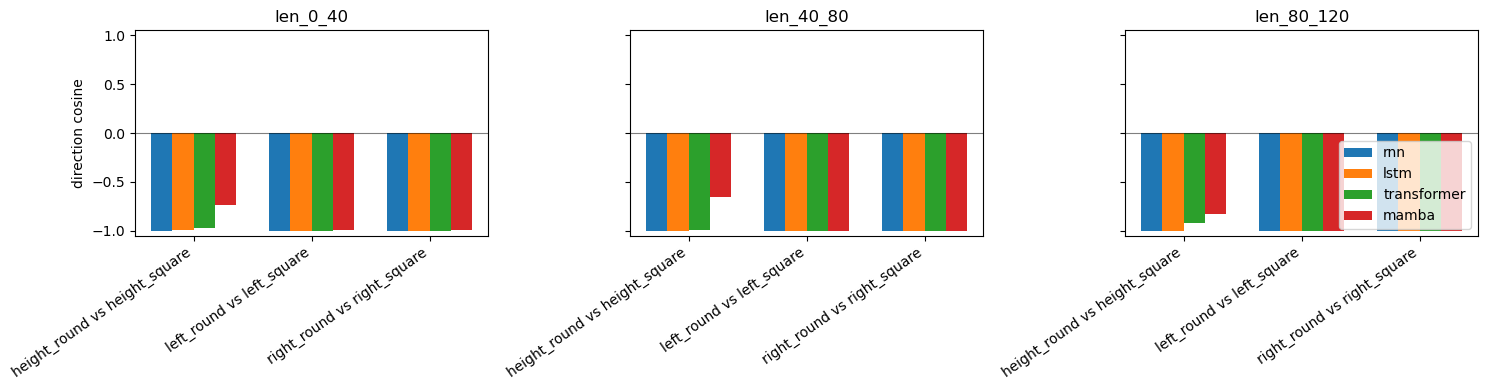

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/counter_orthogonality/fixed_prefix_sum_diff_orthogonality.png


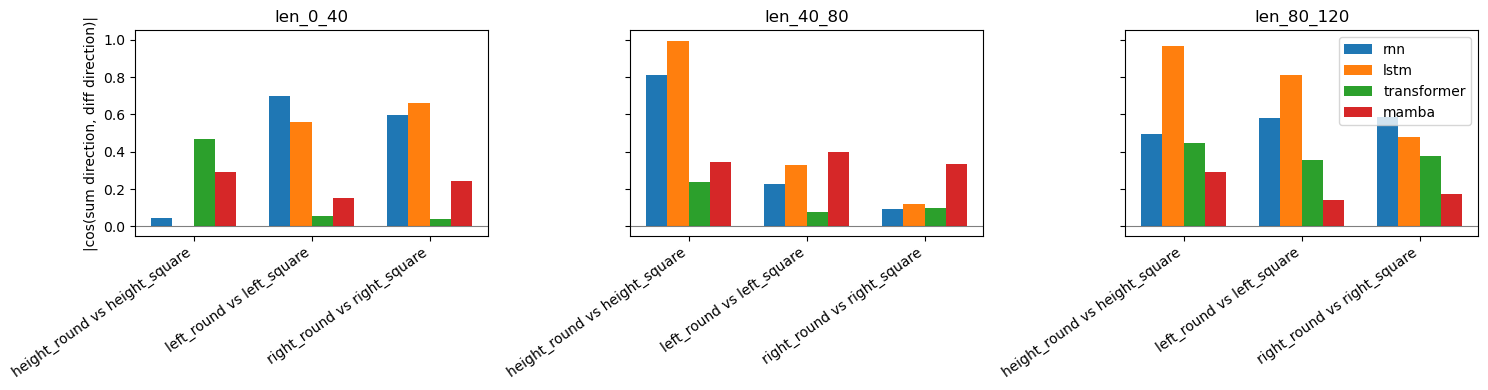

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/counter_orthogonality/prefix_sweep_counter_cosines.png


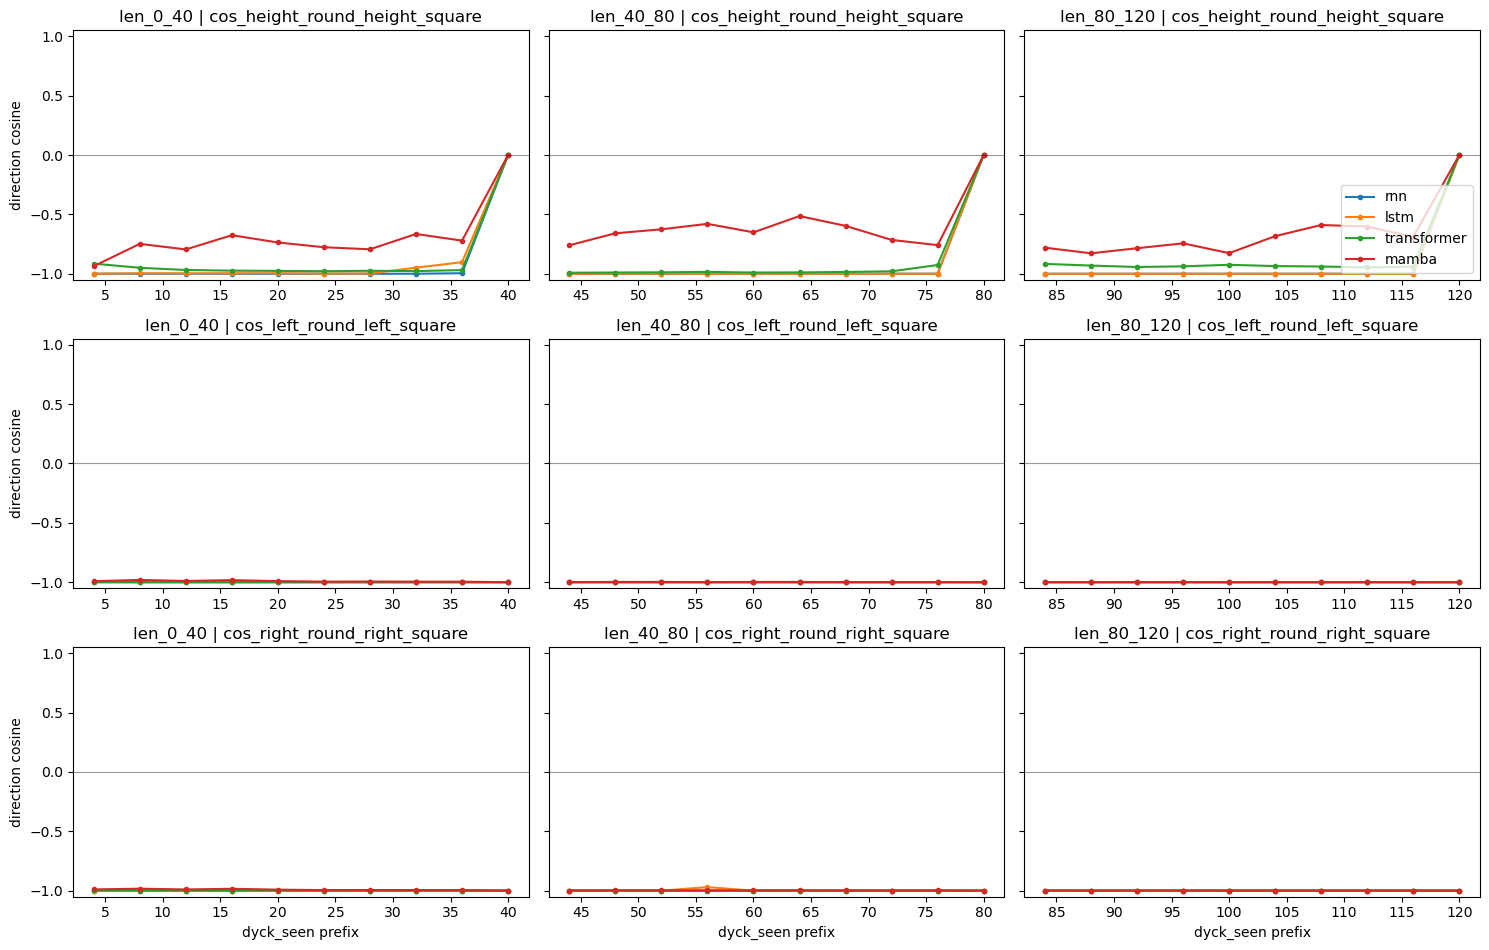

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck23_cfg_next_token/figures/counter_orthogonality/prefix_sweep_sum_diff_orthogonality.png


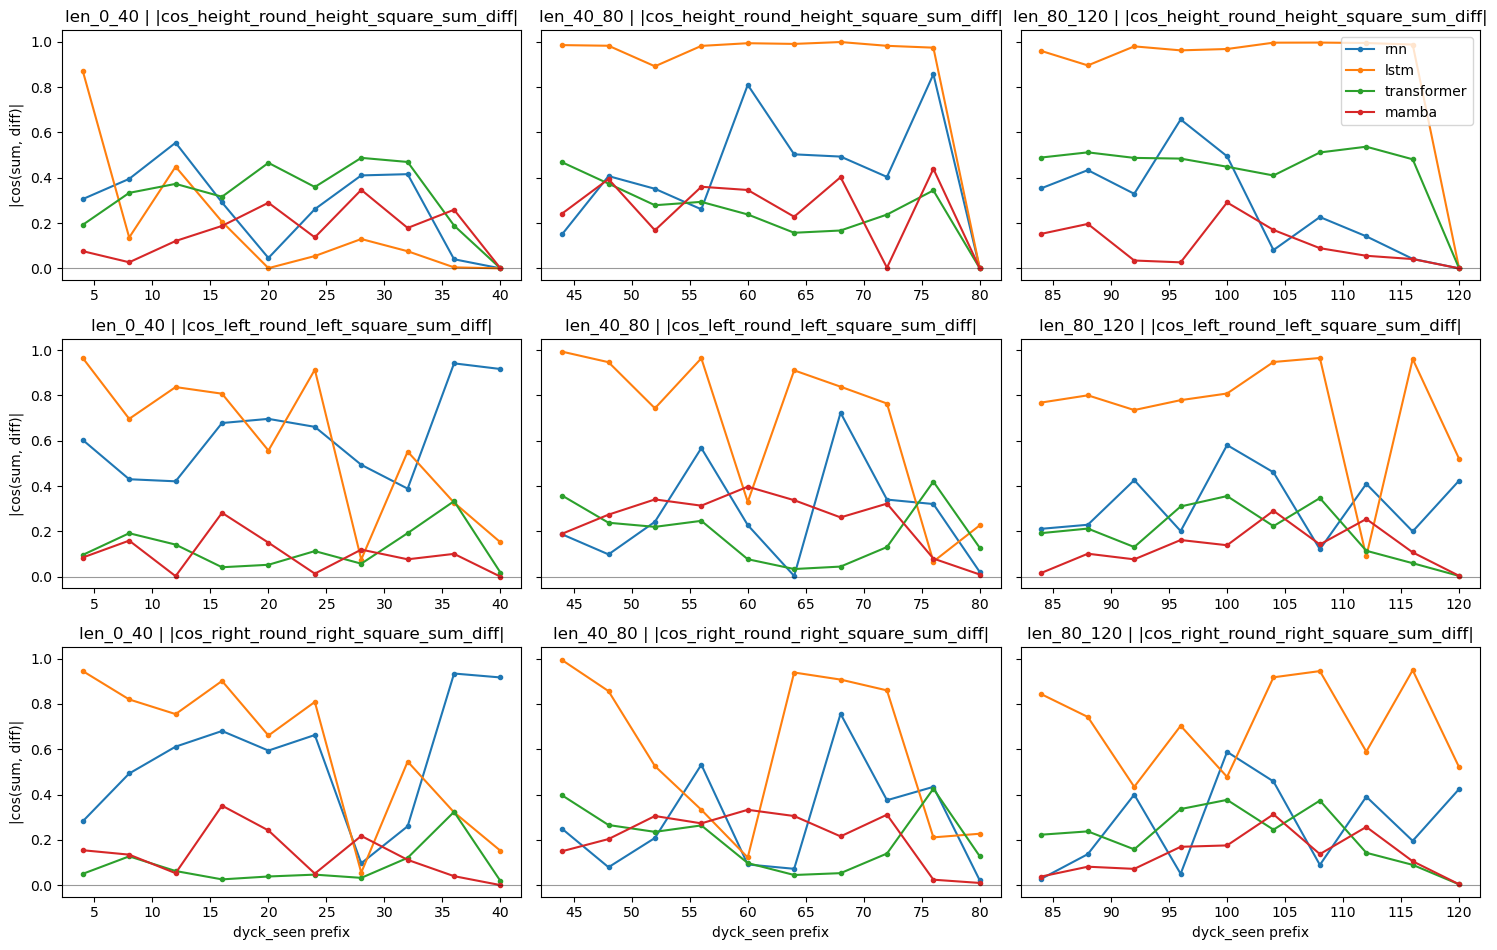

,length_bin,model,prefix,x_target,y_target,x_mae_to_integer,y_mae_to_integer,joint_round_exact,n_grid_points,n
0,len_0_40,rnn,20,height_round,height_square,0.053794,0.053466,0.997396,4,384
1,len_0_40,rnn,20,left_round,left_square,1.170960,1.170906,0.260417,18,384
2,len_0_40,lstm,20,height_round,height_square,0.073874,0.072702,1.000000,4,384
3,len_0_40,lstm,20,left_round,left_square,1.020434,1.020731,0.281250,18,384
4,len_0_40,transformer,20,height_round,height_square,0.059418,0.054887,1.000000,4,384
5,len_0_40,transformer,20,left_round,left_square,0.641951,0.639656,0.445312,18,384
6,len_0_40,mamba,20,height_round,height_square,0.268271,0.229855,0.828125,4,384
7,len_0_40,mamba,20,left_round,left_square,1.214053,1.209860,0.231771,18,384
8,len_40_80,rnn,60,height_round,height_square,0.106308,0.105513,0.968750,4,384
9,len_40_80,rnn,60,left_round,left_square,2.147914,2.147982,0.135417,30,384


In [14]:
def plot_fixed_counter_orthogonality(df):
    if df.empty:
        return
    pair_names = [f'{x} vs {y}' for x, y in COUNTER_TARGET_PAIRS]
    fig, axes = plt.subplots(1, len(DYCK23_LENGTH_BINS), figsize=(15, 4), sharey=True)
    for ax, length_bin in zip(axes, DYCK23_LENGTH_BINS):
        sub = df.loc[df['length_bin'] == length_bin].copy()
        sub['pair'] = sub['x_target'] + ' vs ' + sub['y_target']
        x = np.arange(len(pair_names))
        width = 0.18
        for offset, model_type in enumerate(MODEL_TYPES):
            vals = []
            for pair in pair_names:
                part = sub.loc[(sub['model'] == model_type) & (sub['pair'] == pair), 'cosine']
                vals.append(float(part.iloc[0]) if len(part) else np.nan)
            ax.bar(x + (offset - 1.5) * width, vals, width=width, label=model_type)
        ax.axhline(0.0, color='black', lw=0.8, alpha=0.5)
        ax.set_xticks(x, pair_names, rotation=35, ha='right')
        ax.set_title(length_bin)
        ax.set_ylim(-1.05, 1.05)
    axes[0].set_ylabel('direction cosine')
    axes[-1].legend(loc='lower right')
    finalize_figure(fig, 'counter_orthogonality', 'fixed_prefix_counter_cosines')
    plt.show()
    plt.close(fig)


def plot_counter_orthogonality_sweep(df):
    columns = [_counter_pair_column(x, y) for x, y in COUNTER_TARGET_PAIRS]
    columns = [col for col in columns if col in df]
    if not columns:
        return
    fig, axes = plt.subplots(len(columns), len(DYCK23_LENGTH_BINS), figsize=(15, 3.2 * len(columns)), sharey=True)
    if len(columns) == 1:
        axes = np.array([axes])
    for row, col_name in enumerate(columns):
        for ax, length_bin in zip(axes[row], DYCK23_LENGTH_BINS):
            sub_bin = df.loc[df['length_bin'] == length_bin]
            for model_type in MODEL_TYPES:
                sub = sub_bin.loc[sub_bin['model'] == model_type]
                ax.plot(sub['prefix'], sub[col_name], marker='o', ms=3, label=model_type)
            ax.axhline(0.0, color='black', lw=0.8, alpha=0.4)
            ax.set_title(f'{length_bin} | {col_name}')
            ax.set_ylim(-1.05, 1.05)
            if row == len(columns) - 1:
                ax.set_xlabel('dyck_seen prefix')
            if ax is axes[row][0]:
                ax.set_ylabel('direction cosine')
    axes[0][-1].legend(loc='lower right')
    finalize_figure(fig, 'counter_orthogonality', 'prefix_sweep_counter_cosines')
    plt.show()
    plt.close(fig)


def plot_fixed_counter_basis_orthogonality(df):
    if df.empty or 'abs_cos_sum_diff' not in df:
        return
    pair_names = [f'{x} vs {y}' for x, y in COUNTER_TARGET_PAIRS]
    fig, axes = plt.subplots(1, len(DYCK23_LENGTH_BINS), figsize=(15, 4), sharey=True)
    for ax, length_bin in zip(axes, DYCK23_LENGTH_BINS):
        sub = df.loc[df['length_bin'] == length_bin].copy()
        sub['pair'] = sub['x_target'] + ' vs ' + sub['y_target']
        x = np.arange(len(pair_names))
        width = 0.18
        for offset, model_type in enumerate(MODEL_TYPES):
            vals = []
            for pair in pair_names:
                part = sub.loc[(sub['model'] == model_type) & (sub['pair'] == pair), 'abs_cos_sum_diff']
                vals.append(float(part.iloc[0]) if len(part) else np.nan)
            ax.bar(x + (offset - 1.5) * width, vals, width=width, label=model_type)
        ax.axhline(0.0, color='black', lw=0.8, alpha=0.5)
        ax.set_xticks(x, pair_names, rotation=35, ha='right')
        ax.set_title(length_bin)
        ax.set_ylim(-0.05, 1.05)
    axes[0].set_ylabel('|cos(sum direction, diff direction)|')
    axes[-1].legend(loc='upper right')
    finalize_figure(fig, 'counter_orthogonality', 'fixed_prefix_sum_diff_orthogonality')
    plt.show()
    plt.close(fig)


def plot_counter_basis_sweep(df):
    columns = [f'{_counter_pair_column(x, y)}_sum_diff' for x, y in COUNTER_TARGET_PAIRS]
    columns = [col for col in columns if col in df]
    if not columns:
        return
    fig, axes = plt.subplots(len(columns), len(DYCK23_LENGTH_BINS), figsize=(15, 3.2 * len(columns)), sharey=True)
    if len(columns) == 1:
        axes = np.array([axes])
    for row, col_name in enumerate(columns):
        for ax, length_bin in zip(axes[row], DYCK23_LENGTH_BINS):
            sub_bin = df.loc[df['length_bin'] == length_bin]
            for model_type in MODEL_TYPES:
                sub = sub_bin.loc[sub_bin['model'] == model_type]
                ax.plot(sub['prefix'], sub[col_name].abs(), marker='o', ms=3, label=model_type)
            ax.axhline(0.0, color='black', lw=0.8, alpha=0.4)
            ax.set_title(f'{length_bin} | |{col_name}|')
            ax.set_ylim(-0.05, 1.05)
            if row == len(columns) - 1:
                ax.set_xlabel('dyck_seen prefix')
            if ax is axes[row][0]:
                ax.set_ylabel('|cos(sum, diff)|')
    axes[0][-1].legend(loc='upper right')
    finalize_figure(fig, 'counter_orthogonality', 'prefix_sweep_sum_diff_orthogonality')
    plt.show()
    plt.close(fig)


plot_fixed_counter_orthogonality(fixed_counter_orthogonality_df)
plot_fixed_counter_basis_orthogonality(fixed_counter_orthogonality_df)
plot_counter_orthogonality_sweep(direction_arithmetic_df)
plot_counter_basis_sweep(direction_arithmetic_df)
fixed_counter_grid_df


counter orthogonality 的汇总图：`fixed_prefix_counter_cosines.png`、`fixed_prefix_sum_diff_orthogonality.png`、`prefix_sweep_counter_cosines.png`、`prefix_sweep_sum_diff_orthogonality.png`，并展示 `fixed_counter_grid_df`。

图一说明 ridge probe 学到的 raw round/square 读出方向不是正交的，而是近似反向。因为状态空间受强约束：height_round + height_square <= 3。固定 prefix 下还会有更强的线性关系。所以 round 多的时候 square 往往少，反过来也一样。probe 就容易学到两个相反方向。对 left_round vs left_square 和 right_round vs right_square 更明显，因为在固定 prefix 上累计 open/close 数也强烈 trade-off，所以几乎必然接近 -1。

图二是|cos(sum direction, diff direction)|，sum  = round + square，diff = round - square。理想情况是两者正交。可以看到 Transformer 和 Mamba 在不少位置比较低，说明更像把 counter 拆成总量轴 + 类型差异轴。

图三是 raw counter cosine over prefix，累计 counter 在固定 prefix 上几乎是单自由度 trade-off。比如 round open 多，square open 就少。height_round vs height_square 也大多接近 -1，但 Mamba 没那么负，说明 Mamba 的 per-type height direction 更散、更不稳定。

图四是 sum/diff orthogonality over prefix，还是越接近 0 越说明 sum/diff 两个轴更正交。Transformer/Mamba 往往较低，尤其 left/right counter 上，说明它们的 sum/diff 分解更干净。RNN 有时中等偏高，说明它的状态很离散，但方向几何不一定是正交坐标。LSTM 在很多 prefix 很高，说明 ridge 读出方向纠缠比较强，或者 fixed/prefix 数据约束导致方向不唯一。

这些模型没有把 round counter 和 square counter 编成两个彼此正交的原始轴。
更像是编码：
  1. total counter / total depth
  2. round-square type contrast